# Lista 3 — Padrão de sobrevivência no TITANIC
**Pedro Henrique Lopes de Melo** — Ciência da Computação — Inteligência Artificial — Profa. Cristiane Neri Nobre

Continuação da Questão 03 da Lista 2: mesma base (`titanic completo.csv`, 1.309 passageiros), mesma codificação de atributos e mesmo holdout estratificado 70/30 com `random_state = 23`. Etapas:

1. **Pré-processamento** — imputação (KNN Imputer × MissForest) e balanceamento (SMOTE, na versão SMOTE-NC, × RandomUnderSampler), sempre ajustados só no treino;
2. **Árvore de Decisão** — otimização com Random Search e Otimização Bayesiana (Optuna/TPE) e extração das regras;
3. **Random Forest** — mesmos dois otimizadores;
4. **Avaliação e comparação** — métricas no conjunto de teste para todas as combinações.

> **Colab:** ao executar a célula de leitura, envie o arquivo `titanic completo.csv` (disponível no CANVAS). A execução completa leva alguns minutos, pois são 24 buscas de hiperparâmetros.

In [1]:
# Dependências que não vêm instaladas por padrão no Colab
import importlib.util, subprocess, sys
for pacote, modulo in [('optuna', 'optuna'), ('imbalanced-learn', 'imblearn')]:
    if importlib.util.find_spec(modulo) is None:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', pacote])

## 0. Bibliotecas, leitura e codificação da base

In [2]:
import os, re, time, warnings
os.environ['PYTHONWARNINGS'] = 'ignore'   # também silencia os processos paralelos
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

import sklearn
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import KNNImputer, IterativeImputer
from sklearn.preprocessing import MinMaxScaler
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, ConfusionMatrixDisplay)

import imblearn
from imblearn.over_sampling import SMOTE, SMOTENC
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline

import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 220)
sns.set_theme(style='whitegrid')

SEED = 23
N_JOBS = 4   # processos paralelos (4 para caber na memória de máquinas com 8 GB)
os.makedirs('figuras', exist_ok=True)
os.makedirs('tabelas', exist_ok=True)

def salvar_fig(nome):
    plt.savefig(f'figuras/{nome}.png', dpi=150, bbox_inches='tight')

print('scikit-learn', sklearn.__version__, '| imbalanced-learn', imblearn.__version__,
      '| optuna', optuna.__version__, '| núcleos de CPU:', os.cpu_count())

scikit-learn 1.9.1 | imbalanced-learn 0.14.2 | optuna 5.0.0 | núcleos de CPU: 8


In [3]:
ARQUIVO = 'titanic completo.csv'
if not os.path.exists(ARQUIVO):
    from google.colab import files          # só existe no Colab
    print('Envie o arquivo "titanic completo.csv" (base do CANVAS):')
    ARQUIVO = next(iter(files.upload()))

base = pd.read_csv(ARQUIVO)
print(base.shape)
ausentes = (base.isnull().mean() * 100).round(1)
print('\n% de valores ausentes:')
print(ausentes[ausentes > 0].sort_values(ascending=False))
print('\nDistribuição da classe survived:')
print(base['survived'].value_counts(normalize=True).round(3))

(1309, 14)



% de valores ausentes:
body         90.8
cabin        77.5
boat         62.9
home.dest    43.1
age          20.1
embarked      0.2
fare          0.1
dtype: float64

Distribuição da classe survived:
survived
0    0.618
1    0.382
Name: proportion, dtype: float64


**Codificação (herdada da Lista 2).** `boat`, `body` e `home.dest` são removidos por vazamento de dados (informação posterior ao naufrágio) e `ticket` por não ter semântica. Do nome sai o `titulo`; `cabin` vira o indicador `tem_cabine`; `sex` vira `sexo` (0 = feminino, 1 = masculino); `tam_familia` e `sozinho` são derivados de `sibsp` e `parch`; `titulo` recebe one-hot.

A diferença em relação à Lista 2 está na imputação: lá `age` era preenchida pela mediana por título, `fare` pela mediana por classe e `embarked` pela moda. Agora os valores ausentes são **mantidos como NaN** para serem imputados pelo KNN Imputer e pelo MissForest. `embarked` entra na imputação como código numérico (S = 0, C = 1, Q = 2) e só depois recebe one-hot.

In [4]:
def extrai_titulo(nome):
    t = re.search(r',\s*([^\.]*)\.', nome).group(1).strip()
    if t == 'Mr': return 'Mr'
    if t in ('Mrs', 'Mme', 'Lady', 'the Countess', 'Dona'): return 'Mrs'
    if t in ('Miss', 'Ms', 'Mlle'): return 'Miss'
    if t == 'Master': return 'Master'
    return 'Outros'

df = base.drop(columns=['boat', 'body', 'home.dest', 'ticket'])
df['titulo'] = df['name'].apply(extrai_titulo)
df['tem_cabine'] = df['cabin'].notnull().astype(int)
df['tam_familia'] = df['sibsp'] + df['parch'] + 1
df['sozinho'] = (df['tam_familia'] == 1).astype(int)
df['sexo'] = (df['sex'] == 'male').astype(int)
df['embarque'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})     # NaN preservado

ATRIBUTOS = ['pclass', 'sexo', 'age', 'sibsp', 'parch', 'fare', 'embarque',
             'tem_cabine', 'tam_familia', 'sozinho']
X = pd.concat([df[ATRIBUTOS], pd.get_dummies(df['titulo'], prefix='titulo', dtype=int)], axis=1)
y = df['survived']

# Holdout estratificado 70/30 — o conjunto de teste nunca participa de imputação, balanceamento ou otimização
X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.30, random_state=SEED, stratify=y)
print('treino:', X_treino.shape, '| teste:', X_teste.shape)
pd.DataFrame({'ausentes treino': X_treino.isnull().sum(),
              'ausentes teste': X_teste.isnull().sum()}).query('`ausentes treino` + `ausentes teste` > 0')

treino: (916, 15) | teste: (393, 15)


,ausentes treino,ausentes teste
age,174,89
fare,0,1
embarque,2,0


## 1. Pré-processamento
### 1.a) Imputação de dados ausentes: KNN Imputer × MissForest

Atributos com ausentes: `age` (20,1%), `embarked` (2 registros) e `fare` (1 registro). Ambos os imputadores são **ajustados apenas no treino** e depois aplicados a treino e teste.

* **KNN Imputer** (`KNNImputer`, k = 5): preenche com a média dos 5 passageiros mais parecidos. Os atributos são escalados para [0, 1] antes do cálculo de distância e revertidos depois; sem isso `fare` (0 a 512) dominaria a distância.
* **MissForest** (`IterativeImputer` com `RandomForestRegressor`, 100 árvores, até 10 iterações): cada atributo com ausentes é modelado por uma floresta a partir dos demais, repetindo até convergir. A biblioteca `missingpy` não é compatível com as versões atuais do scikit-learn, por isso foi usada a alternativa indicada no enunciado.
* **Mediana por título** (método da Lista 2): entra apenas como referência.

In [5]:
class ImputadorKNN(BaseEstimator, TransformerMixin):
    def __init__(self, n_neighbors=5):
        self.n_neighbors = n_neighbors
    def fit(self, X, y=None):
        self.escala_ = MinMaxScaler().fit(X)                       # ignora NaN no ajuste
        self.knn_ = KNNImputer(n_neighbors=self.n_neighbors).fit(self.escala_.transform(X))
        return self
    def transform(self, X):
        Z = self.knn_.transform(self.escala_.transform(X))
        return pd.DataFrame(self.escala_.inverse_transform(Z), columns=X.columns, index=X.index)

class ImputadorMissForest(BaseEstimator, TransformerMixin):
    def __init__(self, n_estimators=100, max_iter=10):
        self.n_estimators = n_estimators
        self.max_iter = max_iter
    def fit(self, X, y=None):
        floresta = RandomForestRegressor(n_estimators=self.n_estimators, n_jobs=N_JOBS, random_state=SEED)
        self.imp_ = IterativeImputer(estimator=floresta, max_iter=self.max_iter,
                                     initial_strategy='median', random_state=SEED).fit(X)
        return self
    def transform(self, X):
        return pd.DataFrame(self.imp_.transform(X), columns=X.columns, index=X.index)

class ImputadorMedianaTitulo(BaseEstimator, TransformerMixin):
    # Referência: estratégia usada na Lista 2
    def fit(self, X, y=None):
        titulo = X.filter(like='titulo_').idxmax(axis=1)
        self.idade_ = X['age'].groupby(titulo).median()
        self.tarifa_ = X['fare'].groupby(X['pclass']).median()
        self.embarque_ = X['embarque'].mode()[0]
        return self
    def transform(self, X):
        X = X.copy()
        titulo = X.filter(like='titulo_').idxmax(axis=1)
        X['age'] = X['age'].fillna(titulo.map(self.idade_))
        X['fare'] = X['fare'].fillna(X['pclass'].map(self.tarifa_))
        X['embarque'] = X['embarque'].fillna(self.embarque_)
        return X

TITULOS = ['Master', 'Miss', 'Mr', 'Mrs', 'Outros']
PORTOS = ['S', 'C', 'Q']

def finalizar(D):
    # embarque imputado vira categoria válida (arredonda); título volta a ser uma coluna com código.
    # O one-hot é feito DEPOIS do balanceamento (dentro do pipeline), para o SMOTE-NC tratar cada
    # atributo nominal como uma única variável categórica.
    D = D.copy()
    D['embarque'] = D['embarque'].round().clip(0, 2).astype(int)
    D['titulo'] = D[[f'titulo_{t}' for t in TITULOS]].values.argmax(axis=1)
    return D.drop(columns=[f'titulo_{t}' for t in TITULOS])

class CodificadorOneHot(BaseEstimator, TransformerMixin):
    # one-hot de titulo e embarque com categorias fixas (mesmas colunas em treino, teste e folds)
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        X = X.copy()
        for coluna, categorias, prefixo in [('titulo', TITULOS, 'titulo'), ('embarque', PORTOS, 'embarked')]:
            codigos = X.pop(coluna).round().astype(int)
            for codigo, nome in enumerate(categorias):
                X[f'{prefixo}_{nome}'] = (codigos == codigo).astype(int)
        return X

IMPUTADORES = {'KNN Imputer': ImputadorKNN, 'MissForest': ImputadorMissForest}
dados, tempo_imputacao = {}, {}
for nome, Classe in IMPUTADORES.items():
    t0 = time.perf_counter()
    imp = Classe().fit(X_treino)
    bruto_tr, bruto_te = imp.transform(X_treino), imp.transform(X_teste)
    tempo_imputacao[nome] = time.perf_counter() - t0
    dados[nome] = {'bruto_treino': bruto_tr, 'bruto_teste': bruto_te,
                   'treino': finalizar(bruto_tr), 'teste': finalizar(bruto_te)}
    print(f'{nome}: {tempo_imputacao[nome]:.2f} s')

referencia = ImputadorMedianaTitulo().fit(X_treino)
bruto_ref = referencia.transform(X_treino)

KNN Imputer: 0.06 s


MissForest: 1.84 s


In [6]:
# Valores imputados para os poucos ausentes de fare e embarked
linhas = []
for split, Xo in [('treino', X_treino), ('teste', X_teste)]:
    for col in ['fare', 'embarque']:
        for idx in Xo.index[Xo[col].isna()]:
            linha = {'conjunto': split, 'atributo': 'embarked' if col == 'embarque' else col,
                     'passageiro': base.loc[idx, 'name'], 'pclass': Xo.loc[idx, 'pclass']}
            for nome in IMPUTADORES:
                v = dados[nome]['bruto_' + split].loc[idx, col]
                linha[nome] = f'{v:.2f}' if col == 'fare' else f'{PORTOS[int(np.clip(round(v), 0, 2))]} ({v:.2f})'
            linhas.append(linha)
pd.DataFrame(linhas)

,conjunto,atributo,passageiro,pclass,KNN Imputer,MissForest
0,treino,embarked,"Icard, Miss. Amelie",1,C (0.60),C (0.67)
1,treino,embarked,"Stone, Mrs. George Nelson (Martha Evelyn)",1,C (0.80),C (0.78)
2,teste,fare,"Storey, Mr. Thomas",3,8.18,6.74


**Efeito sobre a distribuição de `age`.** `age` concentra 263 dos 266 ausentes, então é nela que a escolha do método pesa. A comparação é feita no treino entre as idades observadas (antes da imputação) e a coluna completa depois da imputação, usando:

* estatísticas descritivas: média, desvio padrão, quartis e assimetria;
* teste de Kolmogorov-Smirnov (KS) e distância de Wasserstein em relação à distribuição original: quanto menor, mais preservada;
* correlação de `age` com `pclass` e `parch`, para ver se a relação com os outros atributos se mantém;
* **erro de imputação mascarado**: 20% das idades conhecidas são escondidas e imputadas, e o MAE/RMSE mede o quanto cada método acerta o valor real (3 repetições).

In [7]:
ausente_idade = X_treino['age'].isna()
original = X_treino.loc[~ausente_idade, 'age']

def resumo_idade(nome, serie):
    imputados = serie[ausente_idade] if nome != 'Original (observado)' else pd.Series(dtype=float)
    ks = stats.ks_2samp(original, serie)
    return {'Método': nome, 'n': len(serie), 'Média': serie.mean(), 'Desvio': serie.std(),
            'Q1': serie.quantile(.25), 'Mediana': serie.median(), 'Q3': serie.quantile(.75),
            'Assimetria': serie.skew(),
            'Média (só imputados)': imputados.mean(), 'Desvio (só imputados)': imputados.std(),
            'KS': ks.statistic, 'p-valor KS': ks.pvalue,
            'Wasserstein': stats.wasserstein_distance(original, serie),
            'corr(age, pclass)': serie.corr(X_treino.loc[serie.index, 'pclass']),
            'corr(age, parch)': serie.corr(X_treino.loc[serie.index, 'parch'])}

def erro_mascarado(Classe, repeticoes=3, fracao=0.20):
    conhecidos = X_treino.index[~ausente_idade]
    mae, rmse = [], []
    for rep in range(repeticoes):
        ocultos = np.random.RandomState(SEED + rep).choice(conhecidos, int(fracao * len(conhecidos)), replace=False)
        Xm = X_treino.copy()
        Xm.loc[ocultos, 'age'] = np.nan
        erro = Classe().fit(Xm).transform(Xm).loc[ocultos, 'age'] - X_treino.loc[ocultos, 'age']
        mae.append(erro.abs().mean())
        rmse.append(np.sqrt((erro ** 2).mean()))
    return np.mean(mae), np.std(mae), np.mean(rmse)

series = {'Original (observado)': original,
          'KNN Imputer': dados['KNN Imputer']['bruto_treino']['age'],
          'MissForest': dados['MissForest']['bruto_treino']['age'],
          'Mediana por título (Lista 2)': bruto_ref['age']}
tabela_imputacao = pd.DataFrame([resumo_idade(n, s) for n, s in series.items()]).set_index('Método')

classes_imp = {'KNN Imputer': ImputadorKNN, 'MissForest': ImputadorMissForest,
               'Mediana por título (Lista 2)': ImputadorMedianaTitulo}
for nome, Classe in classes_imp.items():
    m, d, r = erro_mascarado(Classe)
    tabela_imputacao.loc[nome, ['MAE mascarado', 'desvio MAE', 'RMSE mascarado']] = [m, d, r]
tabela_imputacao.loc['KNN Imputer', 'Tempo (s)'] = tempo_imputacao['KNN Imputer']
tabela_imputacao.loc['MissForest', 'Tempo (s)'] = tempo_imputacao['MissForest']

tabela_imputacao.to_csv('tabelas/imputacao.csv')
tabela_imputacao.round(3).T

Método,Original (observado),KNN Imputer,MissForest,Mediana por título (Lista 2)
n,742.000,916.000,916.000,916.000
Média,30.080,29.865,29.889,29.719
Desvio,14.075,13.284,13.236,12.968
Q1,21.000,22.000,22.000,22.000
Mediana,29.000,28.000,28.354,30.000
Q3,38.000,36.200,36.936,36.000
Assimetria,0.333,0.326,0.336,0.370
Média (só imputados),NaN,28.948,29.074,28.178
Desvio (só imputados),NaN,9.153,8.795,6.167
KS,0.000,0.064,0.036,0.060


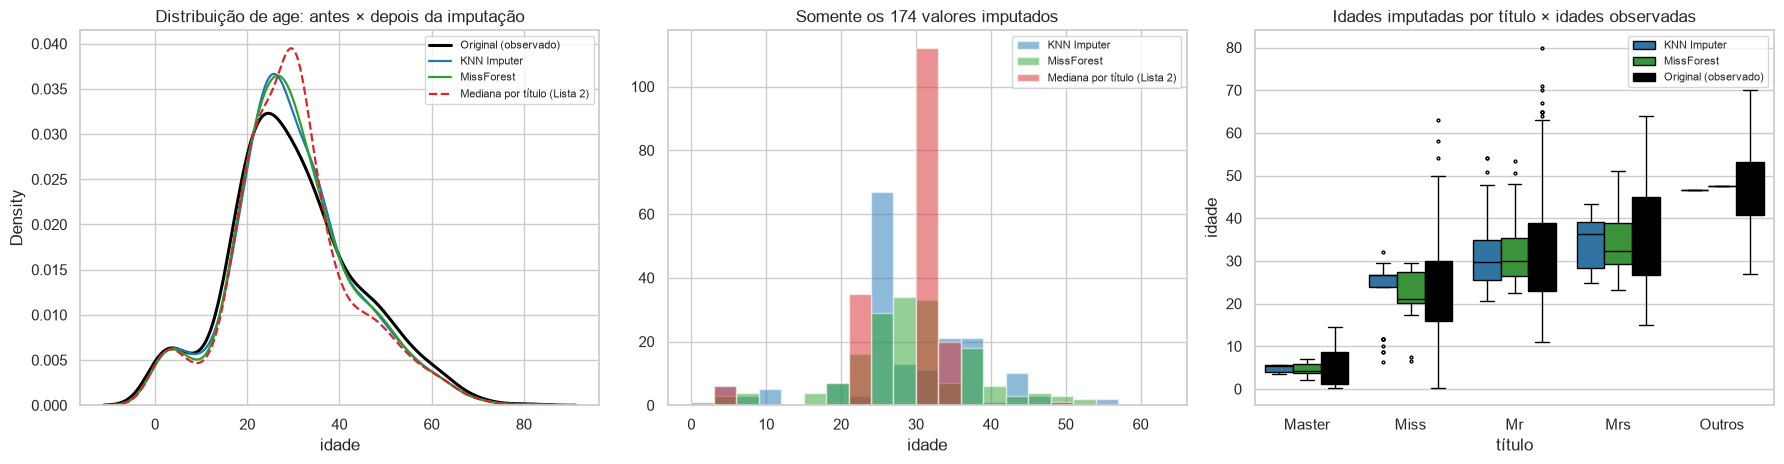

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(18, 4.8))
cores = {'Original (observado)': 'black', 'KNN Imputer': '#1f77b4', 'MissForest': '#2ca02c',
         'Mediana por título (Lista 2)': '#d62728'}
for nome, serie in series.items():
    sns.kdeplot(serie, ax=ax[0], label=nome, color=cores[nome], lw=2.2 if nome.startswith('Orig') else 1.6,
                ls='--' if nome.startswith('Mediana') else '-')
ax[0].set_title('Distribuição de age: antes × depois da imputação'); ax[0].set_xlabel('idade'); ax[0].legend(fontsize=8)

for nome in ['KNN Imputer', 'MissForest', 'Mediana por título (Lista 2)']:
    ax[1].hist(series[nome][ausente_idade], bins=np.arange(0, 66, 3), alpha=.5, label=nome, color=cores[nome])
ax[1].set_title(f'Somente os {ausente_idade.sum()} valores imputados'); ax[1].set_xlabel('idade'); ax[1].legend(fontsize=8)

titulo_treino = X_treino.filter(like='titulo_').idxmax(axis=1).str.replace('titulo_', '')
caixa = pd.concat([pd.DataFrame({'idade': series[n][ausente_idade], 'título': titulo_treino[ausente_idade], 'método': n})
                   for n in ['KNN Imputer', 'MissForest']] +
                  [pd.DataFrame({'idade': original, 'título': titulo_treino[~ausente_idade], 'método': 'Original (observado)'})])
sns.boxplot(data=caixa, x='título', y='idade', hue='método', ax=ax[2],
            palette={k: cores[k] for k in ['Original (observado)', 'KNN Imputer', 'MissForest']},
            order=['Master', 'Miss', 'Mr', 'Mrs', 'Outros'], fliersize=2)
ax[2].set_title('Idades imputadas por título × idades observadas'); ax[2].legend(fontsize=8)
plt.tight_layout(); salvar_fig('imputacao_distribuicao'); plt.show()

**Efeito sobre a distribuição.** Os dois métodos preservam a média (29,9 contra 30,1 da original) e a correlação de *age* com *pclass* (−0,45 contra −0,44), e ambos reduzem o desvio padrão de 14,07 para cerca de 13,25. Essa redução é esperada: um valor estimado a partir de vizinhos ou de uma floresta é uma média condicional e fica sempre mais perto do centro que um valor real. As diferenças aparecem nos detalhes:

* O **MissForest** tem a menor estatística KS (0,036, p = 0,66), contra 0,064 (p = 0,067) do KNN. A distribuição completa depois do MissForest é estatisticamente indistinguível da original, e a do KNN fica no limite da significância. O MissForest também mantém a assimetria (0,336 contra 0,333 da original), espalha os valores imputados de forma mais contínua e tem o menor erro mascarado: MAE de 8,55 ± 0,13 anos, contra 8,68 ± 0,25 do KNN.

* O **KNN Imputer** tem uma distância de Wasserstein um pouco menor (0,84 contra 0,91) e é muito mais rápido (0,06 s contra 1,8 s). Por outro lado, concentra os imputados em poucos valores (pico em torno de 25 anos), porque a média de 5 vizinhos com o mesmo título e a mesma classe se repete.

* A **mediana por título** (Lista 2) é a pior em quase todos os critérios: coloca a maior parte dos imputados em um único valor por título (pico em 30 anos na Figura 1), o desvio dos imputados cai para 6,17 e o MAE sobe para 9,00.

Nos dois ausentes de *embarked* (Amelie Icard e Martha Stone, 1ª classe, mesma cabine e tarifa de 80), os dois métodos imputaram C (Cherbourg). Segundo a Encyclopedia Titanica, as duas embarcaram em Southampton (S), então os dois métodos erraram da mesma forma, com efeito desprezível sobre 2 registros. No único *fare* ausente (3ª classe, no teste), o KNN imputou 8,18 e o MissForest 6,74, ambos valores típicos da 3ª classe.

**Método adotado: MissForest.** Foi o que melhor preservou a forma da distribuição original (menor KS e assimetria mantida) e o que mais acertou idades reais escondidas, com erro também mais estável entre as repetições. O custo de 1,8 s é irrelevante nesta base. Mesmo assim, o item 4 avalia as duas imputações, como o enunciado pede.

In [9]:
IMPUTACAO_ESCOLHIDA = 'MissForest'

### 1.b) Balanceamento de classes: SMOTE (SMOTE-NC) × RandomUnderSampler

No treino, 61,8% dos passageiros não sobreviveram e 38,2% sobreviveram (razão de 1,62 : 1). É um desbalanceamento moderado, com a classe **sobreviveu (1)** como minoritária. Foram comparados:

* **SMOTE**: cria exemplos sintéticos da classe minoritária interpolando cada exemplo com seus vizinhos mais próximos (k = 5) até igualar as classes. O SMOTE clássico interpola *todos* os atributos, e metade da base é binária ou nominal (`sexo`, `tem_cabine`, `sozinho`, `pclass`, `titulo`, `embarque`). Ele gera passageiros com `sexo = 0,37` ou `pclass = 2,6`, e a árvore passa a criar cortes como `sexo <= 0,996`, que só separam exemplos sintéticos (demonstrado abaixo). Por isso foi usado o **SMOTE-NC** (`SMOTENC`), a versão do SMOTE para dados mistos definida no próprio artigo original (Chawla et al., 2002, seção 6.1): interpola os atributos contínuos e, nos categóricos, usa o valor mais frequente entre os vizinhos. Por isso o one-hot de `titulo` e `embarque` é aplicado depois do balanceamento;
* **RandomUnderSampler**: descarta aleatoriamente exemplos da classe majoritária até igualar as classes;
* **Sem balanceamento**: referência para medir se balancear ajuda.

O balanceamento só é aplicado ao treino. Nas buscas de hiperparâmetros ele fica **dentro** de um `imblearn.Pipeline`, então em cada fold da validação cruzada só a parte de treino do fold é reamostrada e a parte de validação mantém a distribuição real. O conjunto de teste nunca é reamostrado.

In [10]:
CATEGORICAS = ['pclass', 'sexo', 'embarque', 'tem_cabine', 'sozinho', 'titulo']
AMOSTRADORES = {'Sem balanceamento': None,
                'SMOTE-NC': lambda: SMOTENC(categorical_features=CATEGORICAS, random_state=SEED),
                'RandomUnderSampler': lambda: RandomUnderSampler(random_state=SEED)}

def contagem(nome, yb, imp):
    c = pd.Series(yb).value_counts().sort_index()
    return {'Imputação': imp, 'Conjunto / técnica': nome, 'Não sobreviveu (0)': c[0], 'Sobreviveu (1)': c[1],
            'Total': len(yb), '% sobreviveu': round(100 * c[1] / len(yb), 1), 'Razão 0:1': round(c[0] / c[1], 2)}

linhas = []
for imp in IMPUTADORES:
    Xtr = dados[imp]['treino']
    linhas.append(contagem('Treino — antes (original)', y_treino, imp))
    for nome in ['SMOTE-NC', 'RandomUnderSampler']:
        _, yb = AMOSTRADORES[nome]().fit_resample(Xtr, y_treino)
        linhas.append(contagem(f'Treino — depois do {nome}', yb, imp))
    linhas.append(contagem('Teste (nunca balanceado)', y_teste, imp))
tabela_balanceamento = pd.DataFrame(linhas)
tabela_balanceamento.to_csv('tabelas/balanceamento.csv', index=False)
tabela_balanceamento

,Imputação,Conjunto / técnica,Não sobreviveu (0),Sobreviveu (1),Total,% sobreviveu,Razão 0:1
0,KNN Imputer,Treino — antes (original),566,350,916,38.2,1.62
1,KNN Imputer,Treino — depois do SMOTE-NC,566,566,1132,50.0,1.00
2,KNN Imputer,Treino — depois do RandomUnderSampler,350,350,700,50.0,1.00
3,KNN Imputer,Teste (nunca balanceado),243,150,393,38.2,1.62
4,MissForest,Treino — antes (original),566,350,916,38.2,1.62
5,MissForest,Treino — depois do SMOTE-NC,566,566,1132,50.0,1.00
6,MissForest,Treino — depois do RandomUnderSampler,350,350,700,50.0,1.00
7,MissForest,Teste (nunca balanceado),243,150,393,38.2,1.62


SMOTE clássico : 216 sintéticos | com algum atributo nominal fracionário: 65.7% | sexo fracionário: 32.4% | pclass fracionário: 19.4%
SMOTE-NC       : 216 sintéticos | com algum atributo nominal fracionário: 0.0% | sexo fracionário: 0.0% | pclass fracionário: 0.0%


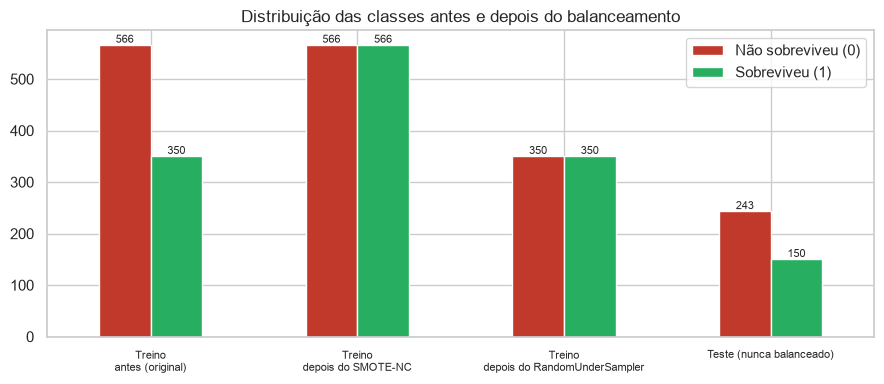

In [11]:
# Por que SMOTE-NC: o SMOTE clássico (sobre os dados já em one-hot) cria categorias inexistentes
Xtr = dados[IMPUTACAO_ESCOLHIDA]['treino']
Xtr_oh = CodificadorOneHot().transform(Xtr)
NOMINAIS = ['pclass', 'sexo', 'tem_cabine', 'sozinho'] + [c for c in Xtr_oh.columns if c.startswith(('titulo_', 'embarked_'))]

def invalidos(sinteticos):
    fora = sinteticos[NOMINAIS] != sinteticos[NOMINAIS].round()
    return fora.any(axis=1).mean(), fora.mean()

X_s, _ = SMOTE(random_state=SEED).fit_resample(Xtr_oh, y_treino)
X_nc, _ = AMOSTRADORES['SMOTE-NC']().fit_resample(Xtr, y_treino)
X_nc = CodificadorOneHot().transform(X_nc)
for nome, Xb in [('SMOTE clássico', X_s), ('SMOTE-NC', X_nc)]:
    linha, por_coluna = invalidos(Xb.iloc[len(Xtr):])
    print(f'{nome:15s}: {len(Xb) - len(Xtr)} sintéticos | com algum atributo nominal fracionário: {linha:.1%} '
          f'| sexo fracionário: {por_coluna["sexo"]:.1%} | pclass fracionário: {por_coluna["pclass"]:.1%}')

t = tabela_balanceamento[tabela_balanceamento['Imputação'] == IMPUTACAO_ESCOLHIDA].set_index('Conjunto / técnica')
ax = t[['Não sobreviveu (0)', 'Sobreviveu (1)']].plot(kind='bar', figsize=(9, 4), color=['#c0392b', '#27ae60'], rot=0)
for p in ax.patches:
    ax.annotate(int(p.get_height()), (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=8)
ax.set_xticklabels([s.replace(' — ', '\n') for s in t.index], fontsize=8)
ax.set_title('Distribuição das classes antes e depois do balanceamento'); ax.set_xlabel('')
plt.tight_layout(); salvar_fig('balanceamento'); plt.show()

As duas técnicas chegam ao mesmo equilíbrio (50% e 50%) por caminhos opostos. O SMOTE-NC aumenta o treino para 1.132 exemplos e preserva toda a informação original. O RandomUnderSampler reduz o treino para 700 e perde 38% dos exemplos de não sobreviventes. O efeito de cada técnica sobre precisão e recall é discutido no item 4.e.

## 2. Árvore de Decisão
### 2.a/b) Treinamento e otimização de hiperparâmetros

Para a comparação entre otimizadores ser justa, os dois recebem as mesmas condições:

| Item | Configuração |
|---|---|
| Otimizadores | **Random Search** (`RandomizedSearchCV`) e **Otimização Bayesiana** (`Optuna`, amostrador TPE) |
| Orçamento | 50 configurações avaliadas por cada um |
| Validação | `StratifiedKFold` com 5 folds e os mesmos folds para os dois |
| Métrica otimizada | F1-macro, que pesa igualmente as duas classes, ao contrário da acurácia, que favorece a majoritária |
| Espaço (AD) | `criterion` ∈ {gini, entropy}, `max_depth` 2–15, `min_samples_split` 2–50, `min_samples_leaf` 1–30 |
| Espaço (RF) | `n_estimators` 50–300, `max_depth` 2–20, `min_samples_split` 2–30, `min_samples_leaf` 1–15, `max_features` ∈ {sqrt, log2, None} |
| Paralelismo | 4 processos em paralelo (`n_jobs = 4`) nos dois otimizadores |

Cada busca é repetida para as **6 combinações** de imputação (KNN, MissForest) × balanceamento (sem, SMOTE-NC, RandomUnderSampler). O tempo medido inclui o re-treino do melhor modelo no treino completo.

In [12]:
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
N_ITER = 50
METRICA = 'f1_macro'
MODELOS = {'Árvore de Decisão': DecisionTreeClassifier, 'Random Forest': RandomForestClassifier}

ESPACO_RANDOM = {
    'Árvore de Decisão': {'criterion': ['gini', 'entropy'], 'max_depth': stats.randint(2, 16),
                          'min_samples_split': stats.randint(2, 51), 'min_samples_leaf': stats.randint(1, 31)},
    'Random Forest': {'n_estimators': stats.randint(50, 301), 'max_depth': stats.randint(2, 21),
                      'min_samples_split': stats.randint(2, 31), 'min_samples_leaf': stats.randint(1, 16),
                      'max_features': ['sqrt', 'log2', None]},
}

def espaco_optuna(trial, modelo):
    if modelo == 'Árvore de Decisão':
        return {'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
                'max_depth': trial.suggest_int('max_depth', 2, 15),
                'min_samples_split': trial.suggest_int('min_samples_split', 2, 50),
                'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 30)}
    return {'n_estimators': trial.suggest_int('n_estimators', 50, 300),
            'max_depth': trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 30),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 15),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None])}

def criar_pipeline(modelo, balanceamento, **params):
    passos = []
    if AMOSTRADORES[balanceamento] is not None:
        passos.append(('balanceamento', AMOSTRADORES[balanceamento]()))
    passos.append(('one_hot', CodificadorOneHot()))
    passos.append(('modelo', MODELOS[modelo](random_state=SEED, **params)))
    return ImbPipeline(passos)

def busca_random(modelo, Xtr, ytr, balanceamento):
    grade = {f'modelo__{k}': v for k, v in ESPACO_RANDOM[modelo].items()}
    busca = RandomizedSearchCV(criar_pipeline(modelo, balanceamento), grade, n_iter=N_ITER,
                               scoring=METRICA, cv=CV, n_jobs=N_JOBS, random_state=SEED)
    t0 = time.perf_counter()
    busca.fit(Xtr, ytr)
    tempo = time.perf_counter() - t0
    return {'params': {k.replace('modelo__', ''): v for k, v in busca.best_params_.items()},
            'cv': busca.best_score_, 'tempo': tempo, 'estimador': busca.best_estimator_,
            'historico': np.maximum.accumulate(busca.cv_results_['mean_test_score'])}

def busca_optuna(modelo, Xtr, ytr, balanceamento):
    def objetivo(trial):
        pipe = criar_pipeline(modelo, balanceamento, **espaco_optuna(trial, modelo))
        return cross_val_score(pipe, Xtr, ytr, cv=CV, scoring=METRICA, n_jobs=N_JOBS).mean()
    estudo = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
    t0 = time.perf_counter()
    estudo.optimize(objetivo, n_trials=N_ITER)
    final = criar_pipeline(modelo, balanceamento, **estudo.best_params).fit(Xtr, ytr)
    tempo = time.perf_counter() - t0
    return {'params': estudo.best_params, 'cv': estudo.best_value, 'tempo': tempo, 'estimador': final,
            'historico': np.maximum.accumulate([t.value for t in estudo.trials])}

OTIMIZADORES = {'Random Search': busca_random, 'Bayesiana (Optuna)': busca_optuna}

def avaliar(estimador, Xtr, ytr, Xte, yte):
    p = estimador.predict(Xte)
    return {'Acurácia treino': accuracy_score(ytr, estimador.predict(Xtr)),
            'Acurácia': accuracy_score(yte, p), 'Precisão': precision_score(yte, p),
            'Recall': recall_score(yte, p), 'F1': f1_score(yte, p),
            'F1-macro': f1_score(yte, p, average='macro'),
            'Precisão (0)': precision_score(yte, p, pos_label=0), 'Recall (0)': recall_score(yte, p, pos_label=0)}

resultados = []
def executar_buscas(modelo):
    for imp in IMPUTADORES:
        Xtr, Xte = dados[imp]['treino'], dados[imp]['teste']
        for bal in AMOSTRADORES:
            for otim, buscar in OTIMIZADORES.items():
                r = buscar(modelo, Xtr, y_treino, bal)
                resultados.append({'Modelo': modelo, 'Imputação': imp, 'Balanceamento': bal, 'Otimizador': otim,
                                   'CV F1-macro': r['cv'], 'Tempo (s)': r['tempo'],
                                   **avaliar(r['estimador'], Xtr, y_treino, Xte, y_teste),
                                   'params': r['params'], 'estimador': r['estimador'], 'historico': r['historico']})
                print(f"{imp:11s} | {bal:18s} | {otim:18s} | CV F1-macro = {r['cv']:.4f} | "
                      f"{r['tempo']:6.1f} s | {r['params']}")

def tabela_hiperparametros(modelo):
    linhas = [{'Imputação': r['Imputação'], 'Balanceamento': r['Balanceamento'], 'Otimizador': r['Otimizador'],
               **r['params'], 'CV F1-macro': round(r['CV F1-macro'], 4), 'Tempo (s)': round(r['Tempo (s)'], 1)}
              for r in resultados if r['Modelo'] == modelo]
    return pd.DataFrame(linhas)

In [13]:
# aquecimento: inicializa o pool de processos paralelos antes de cronometrar (senão a 1ª busca paga esse custo)
cross_val_score(criar_pipeline('Árvore de Decisão', 'SMOTE-NC'), dados['MissForest']['treino'], y_treino, cv=CV, n_jobs=N_JOBS)
executar_buscas('Árvore de Decisão')

KNN Imputer | Sem balanceamento  | Random Search      | CV F1-macro = 0.7888 |    0.6 s | {'criterion': 'entropy', 'max_depth': 6, 'min_samples_leaf': 1, 'min_samples_split': 26}


KNN Imputer | Sem balanceamento  | Bayesiana (Optuna) | CV F1-macro = 0.7906 |    1.6 s | {'criterion': 'entropy', 'max_depth': 7, 'min_samples_split': 30, 'min_samples_leaf': 2}


KNN Imputer | SMOTE-NC           | Random Search      | CV F1-macro = 0.7857 |    3.2 s | {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 17, 'min_samples_split': 8}


KNN Imputer | SMOTE-NC           | Bayesiana (Optuna) | CV F1-macro = 0.7830 |    4.9 s | {'criterion': 'entropy', 'max_depth': 6, 'min_samples_split': 20, 'min_samples_leaf': 3}


KNN Imputer | RandomUnderSampler | Random Search      | CV F1-macro = 0.7804 |    1.0 s | {'criterion': 'entropy', 'max_depth': 7, 'min_samples_leaf': 1, 'min_samples_split': 14}


...

MissForest  | Sem balanceamento  | Bayesiana (Optuna) | CV F1-macro = 0.7863 |    1.4 s | {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 26, 'min_samples_leaf': 2}


MissForest  | SMOTE-NC           | Random Search      | CV F1-macro = 0.7792 |    2.1 s | {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 17, 'min_samples_split': 8}


MissForest  | SMOTE-NC           | Bayesiana (Optuna) | CV F1-macro = 0.7805 |    3.3 s | {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 9, 'min_samples_leaf': 11}


MissForest  | RandomUnderSampler | Random Search      | CV F1-macro = 0.7785 |    0.5 s | {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 3, 'min_samples_split': 13}


MissForest  | RandomUnderSampler | Bayesiana (Optuna) | CV F1-macro = 0.7795 |    1.4 s | {'criterion': 'gini', 'max_depth': 4, 'min_samples_split': 26, 'min_samples_leaf': 8}


### 2.c) Melhores hiperparâmetros e tempo de busca — Árvore de Decisão

In [14]:
hiper_ad = tabela_hiperparametros('Árvore de Decisão')
hiper_ad.to_csv('tabelas/hiperparametros_ad.csv', index=False)
hiper_ad

,Imputação,Balanceamento,Otimizador,criterion,max_depth,min_samples_leaf,min_samples_split,CV F1-macro,Tempo (s)
0,KNN Imputer,Sem balanceamento,Random Search,entropy,6,1,26,0.7888,0.6
1,KNN Imputer,Sem balanceamento,Bayesiana (Optuna),entropy,7,2,30,0.7906,1.6
2,KNN Imputer,SMOTE-NC,Random Search,gini,5,17,8,0.7857,3.2
3,KNN Imputer,SMOTE-NC,Bayesiana (Optuna),entropy,6,3,20,0.7830,4.9
4,KNN Imputer,RandomUnderSampler,Random Search,entropy,7,1,14,0.7804,1.0
5,KNN Imputer,RandomUnderSampler,Bayesiana (Optuna),gini,6,3,15,0.7870,1.9
6,MissForest,Sem balanceamento,Random Search,entropy,6,1,26,0.7826,0.7
7,MissForest,Sem balanceamento,Bayesiana (Optuna),gini,5,2,26,0.7863,1.4
8,MissForest,SMOTE-NC,Random Search,gini,5,17,8,0.7792,2.1
9,MissForest,SMOTE-NC,Bayesiana (Optuna),gini,4,11,9,0.7805,3.3


**Árvore de Decisão (2.c).** As melhores árvores ficaram entre profundidade 3 e 7, com gini em 7 das 12 buscas e entropy em 5, e o F1-macro de validação variou pouco, de 0,779 a 0,791. O Random Search levou em média 1,4 s por busca e o Optuna, 2,4 s.

Algumas configurações do Random Search se repetem entre combinações, como n_estimators = 269, max_depth = 10, min_samples_leaf = 5 e max_features = None em três delas. Isso ocorre porque a mesma semente sorteia os mesmos 50 candidatos em todas as buscas, e só muda qual deles vence conforme os dados de cada combinação.

### 2.d) Regras da Árvore de Decisão otimizada

As regras vêm da árvore com **maior F1-macro na validação cruzada** entre as configurações que usam a imputação escolhida. A escolha pela validação cruzada, e não pelo teste, evita ajustar a decisão ao conjunto de teste. Além do `export_text` e do `plot_tree`, cada folha é convertida em uma regra SE–ENTÃO com as condições simplificadas: limites repetidos sobre o mesmo atributo são fundidos e atributos binários aparecem como categoria. A qualidade de cada regra é medida pela **cobertura**, a fração de passageiros que satisfazem a regra, e pela **confiança**, a fração desses em que a classe prevista está correta. As duas são calculadas no treino original (sem exemplos sintéticos) e no teste.

In [15]:
candidatas = [r for r in resultados if r['Modelo'] == 'Árvore de Decisão' and r['Imputação'] == IMPUTACAO_ESCOLHIDA]
melhor_ad = max(candidatas, key=lambda r: r['CV F1-macro'])
arvore = melhor_ad['estimador'].named_steps['modelo']
conj_treino = CodificadorOneHot().transform(dados[IMPUTACAO_ESCOLHIDA]['treino'])
conj_teste = CodificadorOneHot().transform(dados[IMPUTACAO_ESCOLHIDA]['teste'])
nomes = list(conj_treino.columns)
print(f"Configuração: {melhor_ad['Imputação']} + {melhor_ad['Balanceamento']} + {melhor_ad['Otimizador']}")
print(f"Hiperparâmetros: {melhor_ad['params']}")
print(f"Profundidade real: {arvore.get_depth()} | folhas (= regras): {arvore.get_n_leaves()}")
print()
print(export_text(arvore, feature_names=nomes, decimals=2))

Configuração: MissForest + Sem balanceamento + Bayesiana (Optuna)
Hiperparâmetros: {'criterion': 'gini', 'max_depth': 5, 'min_samples_split': 26, 'min_samples_leaf': 2}
Profundidade real: 5 | folhas (= regras): 21

|--- sexo <= 0.50
|   |--- pclass <= 2.50
|   |   |--- fare <= 26.12
|   |   |   |--- tem_cabine <= 0.50
|   |   |   |   |--- titulo_Miss <= 0.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- titulo_Miss >  0.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- tem_cabine >  0.50
|   |   |   |   |--- class: 1
|   |   |--- fare >  26.12
|   |   |   |--- fare <= 31.68
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  31.68
|   |   |   |   |--- tam_familia <= 3.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- tam_familia >  3.50
|   |   |   |   |   |--- class: 1
|   |--- pclass >  2.50
|   |   |--- fare <= 23.35
|   |   |   |--- fare <= 7.74
|   |   |   |   |--- class: 1
|   |   |   |--- fare >  7.74
|   |   |   |   |--- age <= 27.74
|   |   |   |   |   

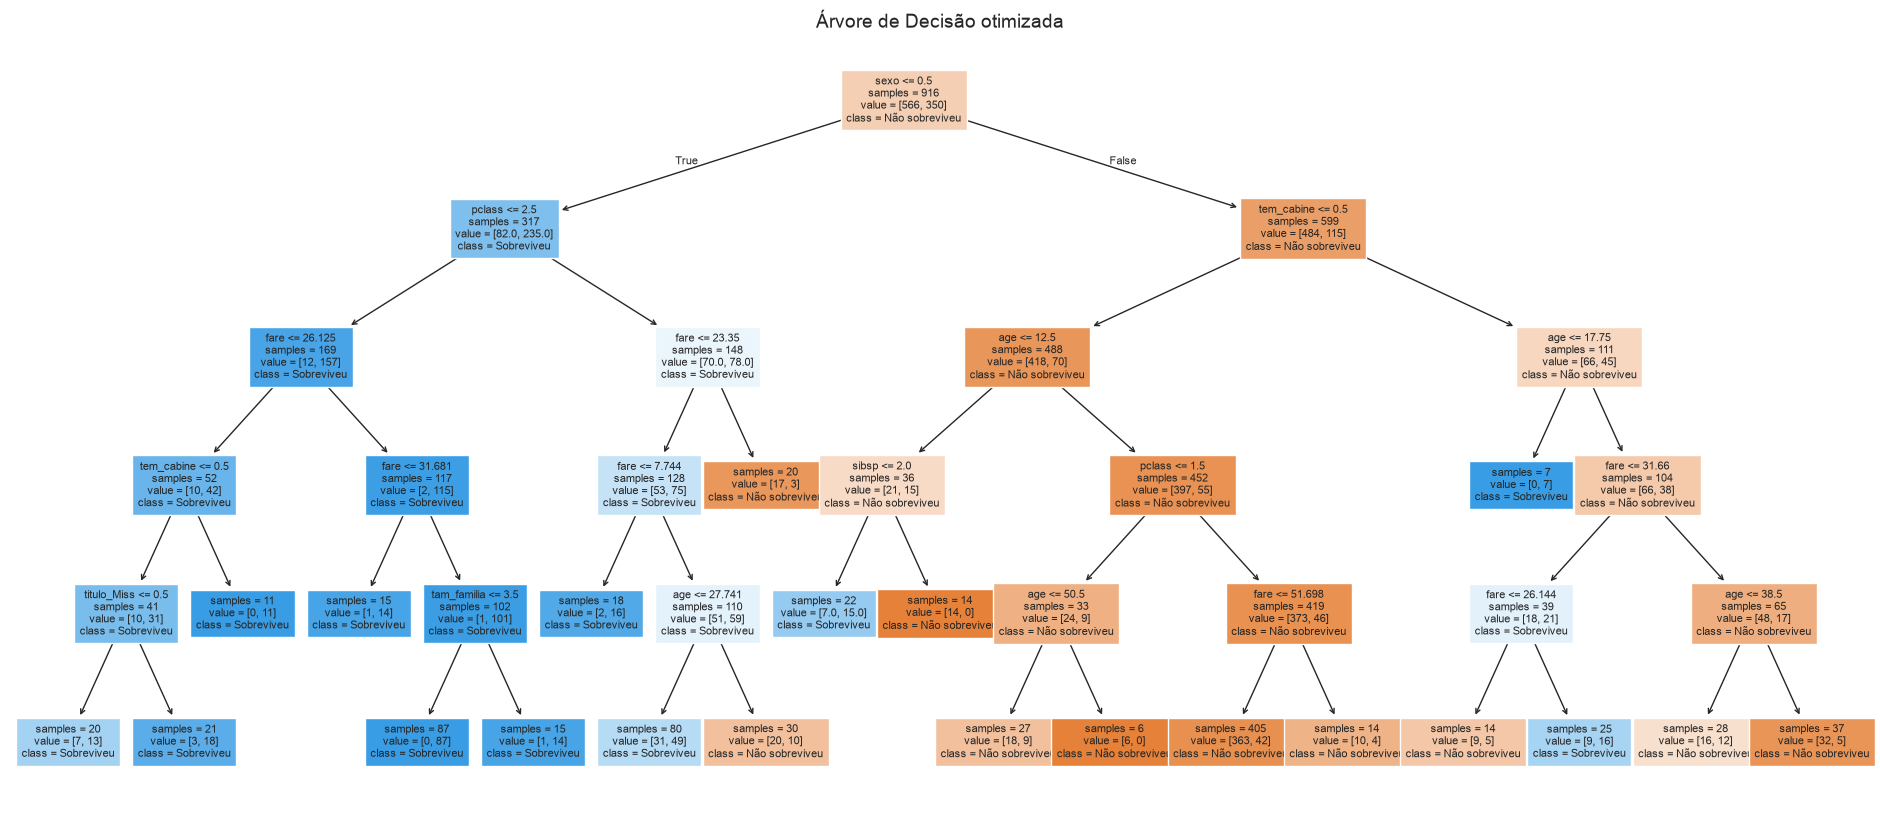

In [16]:
profundidade_plot = None if arvore.get_n_leaves() <= 24 else 4
fig, ax = plt.subplots(figsize=(24, 10))
plot_tree(arvore, feature_names=nomes, class_names=['Não sobreviveu', 'Sobreviveu'], filled=True,
          impurity=False, proportion=False, fontsize=8, max_depth=profundidade_plot, ax=ax)
titulo = 'Árvore de Decisão otimizada' + ('' if profundidade_plot is None else f' (primeiros {profundidade_plot} níveis)')
ax.set_title(titulo, fontsize=14)
salvar_fig('arvore_otimizada'); plt.show()

In [17]:
BINARIOS = {'sexo': ('mulher', 'homem'), 'tem_cabine': ('sem cabine', 'com cabine'), 'sozinho': ('acompanhado', 'sozinho')}
INTEIROS = {'pclass': 'classe', 'sibsp': 'sibsp', 'parch': 'parch', 'tam_familia': 'família'}
CONTINUOS = {'age': 'idade', 'fare': 'tarifa'}

def condicao(atributo, inferior, superior):
    # inferior: atributo > limite ; superior: atributo <= limite
    if atributo in BINARIOS:
        return BINARIOS[atributo][1] if inferior is not None else BINARIOS[atributo][0]
    if atributo.startswith('titulo_'):
        return f"título = {atributo[7:]}" if inferior is not None else f"título ≠ {atributo[7:]}"
    if atributo.startswith('embarked_'):
        return f"embarque = {atributo[9:]}" if inferior is not None else f"embarque ≠ {atributo[9:]}"
    if atributo in INTEIROS:
        nome = INTEIROS[atributo]
        lo = None if inferior is None else int(np.floor(inferior)) + 1
        hi = None if superior is None else int(np.floor(superior))
        if lo is not None and hi is not None:
            return f'{nome} = {lo}' if lo == hi else f'{nome} de {lo} a {hi}'
        return f'{nome} ≥ {lo}' if lo is not None else f'{nome} ≤ {hi}'
    nome = CONTINUOS.get(atributo, atributo)
    if inferior is not None and superior is not None:
        return f'{inferior:.1f} < {nome} ≤ {superior:.1f}'
    return f'{nome} > {inferior:.1f}' if inferior is not None else f'{nome} ≤ {superior:.1f}'

def extrair_regras(arvore, nomes, conjuntos):
    t = arvore.tree_
    folhas = {nome: arvore.apply(Xc) for nome, (Xc, _) in conjuntos.items()}
    regras = []
    def descer(no, limites):
        if t.children_left[no] == -1:
            classe = arvore.classes_[np.argmax(t.value[no][0])]
            regra = {'Regra': 'SE ' + ' E '.join(condicao(a, lo, hi) for a, (lo, hi) in limites.items()),
                     'Classe': 'SOBREVIVEU' if classe == 1 else 'NÃO SOBREVIVEU'}
            for nome, (Xc, yc) in conjuntos.items():
                cobre = folhas[nome] == no
                regra[f'Cobertura ({nome})'] = cobre.mean()
                regra[f'Confiança ({nome})'] = (np.asarray(yc)[cobre] == classe).mean() if cobre.any() else np.nan
            regra['n (teste)'] = int((folhas['teste'] == no).sum())
            regras.append(regra)
            return
        a, limiar = nomes[t.feature[no]], t.threshold[no]
        lo, hi = limites.get(a, (None, None))
        descer(t.children_left[no], {**limites, a: (lo, limiar if hi is None else min(hi, limiar))})
        descer(t.children_right[no], {**limites, a: (limiar if lo is None else max(lo, limiar), hi)})
    descer(0, {})
    return pd.DataFrame(regras)

regras = extrair_regras(arvore, nomes, {'treino': (conj_treino, y_treino), 'teste': (conj_teste, y_teste)})
regras = regras.sort_values(['Classe', 'Cobertura (treino)'], ascending=[False, False]).reset_index(drop=True)
regras.index = [f'R{i + 1}' for i in range(len(regras))]
regras.to_csv('tabelas/regras_ad.csv')

importancia_ad = pd.Series(arvore.feature_importances_, index=nomes).sort_values(ascending=False)
print('Importância dos atributos (AD):')
print(importancia_ad[importancia_ad > 0].round(3).to_string())
with pd.option_context('display.max_colwidth', 120):
    display(regras.style.format({c: '{:.1%}' for c in regras.columns if c.startswith(('Cobertura', 'Confiança'))}))

Importância dos atributos (AD):
sexo           0.591
pclass         0.128
fare           0.089
age            0.087
tem_cabine     0.063
sibsp          0.038
titulo_Miss    0.004
tam_familia    0.001


,Regra,Classe,Cobertura (treino),Confiança (treino),Cobertura (teste),Confiança (teste),n (teste)
R1,SE mulher E classe ≤ 2 E tarifa > 31.7 E família ≤ 3,SOBREVIVEU,9.5%,100.0%,9.4%,97.3%,37
R2,SE mulher E classe ≥ 3 E 7.7 < tarifa ≤ 23.4 E idade ≤ 27.7,SOBREVIVEU,8.7%,61.3%,9.7%,55.3%,38
R3,SE homem E com cabine E idade > 17.8 E 26.1 < tarifa ≤ 31.7,SOBREVIVEU,2.7%,64.0%,2.5%,30.0%,10
R4,SE homem E sem cabine E idade ≤ 12.5 E sibsp ≤ 2,SOBREVIVEU,2.4%,68.2%,1.8%,85.7%,7
R5,SE mulher E classe ≤ 2 E tarifa ≤ 26.1 E sem cabine E título = Miss,SOBREVIVEU,2.3%,85.7%,2.8%,100.0%,11
R6,SE mulher E classe ≤ 2 E tarifa ≤ 26.1 E sem cabine E título ≠ Miss,SOBREVIVEU,2.2%,65.0%,3.6%,92.9%,14
R7,SE mulher E classe ≥ 3 E tarifa ≤ 7.7,SOBREVIVEU,2.0%,88.9%,2.0%,50.0%,8
R8,SE mulher E classe ≤ 2 E 26.1 < tarifa ≤ 31.7,SOBREVIVEU,1.6%,93.3%,2.8%,90.9%,11
R9,SE mulher E classe ≤ 2 E tarifa > 31.7 E família ≥ 4,SOBREVIVEU,1.6%,93.3%,1.5%,83.3%,6
R10,SE mulher E classe ≤ 2 E tarifa ≤ 26.1 E com cabine,SOBREVIVEU,1.2%,100.0%,0.5%,50.0%,2


**Padrão de sobrevivência e mortalidade encontrado:**

* **O sexo continua sendo o fator dominante**, com 59% da importância e posição de raiz na árvore. A maior regra, R12, cobre 43% dos passageiros do teste: *homem com mais de 12,5 anos, sem cabine registrada, de 2ª ou 3ª classe* morreu em 87,5% dos casos.

* **Mulheres de 1ª e 2ª classe sobreviveram** em quase todas as situações: R1, R5, R6, R8 e R9 têm confiança de 83% a 100% no teste. Só R1 cobre 9,4% do teste, com 97,3% de acerto.

* **Na 3ª classe, a tarifa separa as mulheres.** Com tarifa acima de 23,4 (bilhetes coletivos de famílias numerosas), elas morreram em 100% dos casos do teste (R17), o mesmo padrão da regra de famílias grandes da Lista 2. Com tarifa intermediária, as de até 27,7 anos sobreviveram em apenas 55% dos casos (R2), praticamente um sorteio.

* **"Mulheres e crianças primeiro" valeu para meninos de famílias pequenas.** Meninos de até 12,5 anos sem cabine sobreviveram em 86% dos casos quando tinham no máximo 2 irmãos a bordo (R4) e morreram em 86% quando tinham 3 ou mais (R18). Entre os homens com cabine, os menores de 17,8 anos sobreviveram (R11).

* **Regras frágeis:** R3 (homem com cabine, tarifa entre 26,1 e 31,7, sobreviveu) tem 64% de confiança no treino e só 30% no teste, e R13 cai de 86,5% para 53,8%. São folhas pequenas que capturaram ruído do treino e seriam as primeiras a desaparecer com uma poda mais agressiva.

Em resumo, o padrão da Lista 2 se confirma com mais detalhe: sobreviveram as mulheres das classes altas e as crianças de famílias pequenas; morreram os homens adultos, principalmente de 2ª e 3ª classe, e as famílias numerosas da 3ª classe.

## 3. Random Forest
### 3.a/b) Treinamento e otimização com os mesmos dois otimizadores

Mesmo protocolo da Árvore de Decisão: mesmas 6 combinações de pré-processamento, 50 avaliações por otimizador, os mesmos folds e a mesma métrica. Cada floresta roda com `n_jobs = 1` para que o paralelismo fique só entre os folds, igual para os dois otimizadores.

In [18]:
executar_buscas('Random Forest')

KNN Imputer | Sem balanceamento  | Random Search      | CV F1-macro = 0.8038 |    9.7 s | {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 269}


KNN Imputer | Sem balanceamento  | Bayesiana (Optuna) | CV F1-macro = 0.8048 |   12.6 s | {'n_estimators': 109, 'max_depth': 9, 'min_samples_split': 18, 'min_samples_leaf': 4, 'max_features': None}


KNN Imputer | SMOTE-NC           | Random Search      | CV F1-macro = 0.7981 |   11.7 s | {'max_depth': 10, 'max_features': 'log2', 'min_samples_leaf': 2, 'min_samples_split': 16, 'n_estimators': 103}


KNN Imputer | SMOTE-NC           | Bayesiana (Optuna) | CV F1-macro = 0.8022 |   14.7 s | {'n_estimators': 128, 'max_depth': 12, 'min_samples_split': 25, 'min_samples_leaf': 5, 'max_features': 'log2'}


KNN Imputer | RandomUnderSampler | Random Search      | CV F1-macro = 0.7977 |   10.1 s | {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 269}


...

MissForest  | Sem balanceamento  | Bayesiana (Optuna) | CV F1-macro = 0.7965 |   13.0 s | {'n_estimators': 58, 'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 2, 'max_features': None}


MissForest  | SMOTE-NC           | Random Search      | CV F1-macro = 0.7958 |   12.6 s | {'max_depth': 6, 'max_features': 'sqrt', 'min_samples_leaf': 7, 'min_samples_split': 11, 'n_estimators': 106}


MissForest  | SMOTE-NC           | Bayesiana (Optuna) | CV F1-macro = 0.7994 |   18.3 s | {'n_estimators': 215, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'log2'}


MissForest  | RandomUnderSampler | Random Search      | CV F1-macro = 0.7912 |    8.9 s | {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 269}


MissForest  | RandomUnderSampler | Bayesiana (Optuna) | CV F1-macro = 0.7951 |   11.7 s | {'n_estimators': 100, 'max_depth': 16, 'min_samples_split': 18, 'min_samples_leaf': 1, 'max_features': None}


### 3.c) Melhores hiperparâmetros e tempo de busca — Random Forest

In [19]:
hiper_rf = tabela_hiperparametros('Random Forest')
hiper_rf.to_csv('tabelas/hiperparametros_rf.csv', index=False)
hiper_rf

,Imputação,Balanceamento,Otimizador,max_depth,max_features,min_samples_leaf,min_samples_split,n_estimators,CV F1-macro,Tempo (s)
0,KNN Imputer,Sem balanceamento,Random Search,10,NaN,5,2,269,0.8038,9.7
1,KNN Imputer,Sem balanceamento,Bayesiana (Optuna),9,NaN,4,18,109,0.8048,12.6
2,KNN Imputer,SMOTE-NC,Random Search,10,log2,2,16,103,0.7981,11.7
3,KNN Imputer,SMOTE-NC,Bayesiana (Optuna),12,log2,5,25,128,0.8022,14.7
4,KNN Imputer,RandomUnderSampler,Random Search,10,NaN,5,2,269,0.7977,10.1
5,KNN Imputer,RandomUnderSampler,Bayesiana (Optuna),13,NaN,6,11,214,0.7986,12.9
6,MissForest,Sem balanceamento,Random Search,10,log2,2,16,103,0.7960,9.8
7,MissForest,Sem balanceamento,Bayesiana (Optuna),14,NaN,2,19,58,0.7965,13.0
8,MissForest,SMOTE-NC,Random Search,6,sqrt,7,11,106,0.7958,12.6
9,MissForest,SMOTE-NC,Bayesiana (Optuna),10,log2,9,15,215,0.7994,18.3


**Random Forest (3.c).** As florestas preferiram árvores mais profundas (max_depth de 6 a 16), já que a média de várias árvores compensa a variância de cada uma, e escolheram max_features = None em 7 das 12 buscas. O número de árvores variou muito, de 58 a 269, sem mudar a validação (0,791 a 0,805), o que indica que esse hiperparâmetro pesa pouco nesta base. Tempo médio por busca: 10,5 s no Random Search e 13,9 s no Optuna.

## 4. Avaliação e comparação dos resultados
### 4.a) Métricas no conjunto de teste para todas as combinações

Precisão, recall e F1 referem-se à classe **sobreviveu (1)**, a minoritária. As colunas "(0)" referem-se a não sobreviveu. O teste tem 393 passageiros, então o erro padrão da acurácia fica em torno de ±2 p.p. e diferenças menores que isso não devem ser tratadas como relevantes.

In [20]:
COLUNAS = ['Modelo', 'Imputação', 'Balanceamento', 'Otimizador', 'CV F1-macro', 'Acurácia treino', 'Acurácia',
           'Precisão', 'Recall', 'F1', 'F1-macro', 'Precisão (0)', 'Recall (0)', 'Tempo (s)']
metricas = pd.DataFrame(resultados)[COLUNAS]
metricas.to_csv('tabelas/metricas.csv', index=False)
metricas.style.format({c: '{:.3f}' for c in COLUNAS[4:-1]} | {'Tempo (s)': '{:.1f}'}) \
    .background_gradient(subset=['Acurácia', 'F1', 'F1-macro'], cmap='Greens')

,Modelo,Imputação,Balanceamento,Otimizador,CV F1-macro,Acurácia treino,Acurácia,Precisão,Recall,F1,F1-macro,Precisão (0),Recall (0),Tempo (s)
0,Árvore de Decisão,KNN Imputer,Sem balanceamento,Random Search,0.789,0.844,0.786,0.717,0.727,0.722,0.774,0.830,0.823,0.6
1,Árvore de Decisão,KNN Imputer,Sem balanceamento,Bayesiana (Optuna),0.791,0.837,0.791,0.758,0.667,0.709,0.773,0.808,0.868,1.6
2,Árvore de Decisão,KNN Imputer,SMOTE-NC,Random Search,0.786,0.830,0.799,0.729,0.753,0.741,0.788,0.845,0.827,3.2
3,Árvore de Decisão,KNN Imputer,SMOTE-NC,Bayesiana (Optuna),0.783,0.838,0.804,0.732,0.767,0.749,0.794,0.852,0.827,4.9
4,Árvore de Decisão,KNN Imputer,RandomUnderSampler,Random Search,0.780,0.844,0.779,0.693,0.753,0.722,0.769,0.839,0.794,1.0
5,Árvore de Decisão,KNN Imputer,RandomUnderSampler,Bayesiana (Optuna),0.787,0.833,0.786,0.701,0.767,0.732,0.777,0.847,0.798,1.9
6,Árvore de Decisão,MissForest,Sem balanceamento,Random Search,0.783,0.841,0.807,0.753,0.733,0.743,0.794,0.838,0.852,0.7
7,Árvore de Decisão,MissForest,Sem balanceamento,Bayesiana (Optuna),0.786,0.835,0.819,0.769,0.753,0.761,0.808,0.850,0.860,1.4
8,Árvore de Decisão,MissForest,SMOTE-NC,Random Search,0.779,0.829,0.809,0.752,0.747,0.749,0.798,0.844,0.848,2.1
9,Árvore de Decisão,MissForest,SMOTE-NC,Bayesiana (Optuna),0.781,0.818,0.802,0.722,0.780,0.750,0.793,0.857,0.815,3.3


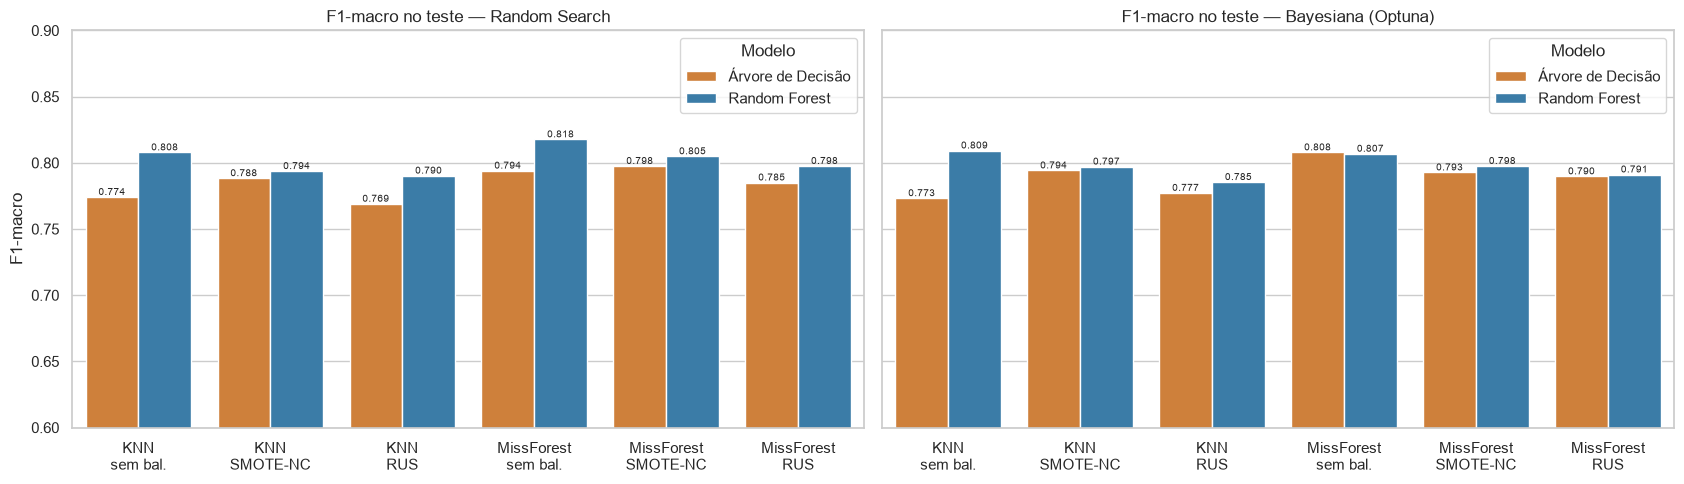

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(17, 5), sharey=True)
for i, otim in enumerate(OTIMIZADORES):
    m = metricas[metricas['Otimizador'] == otim].copy()
    m['Combinação'] = m['Imputação'].str.replace(' Imputer', '') + '\n' + m['Balanceamento'].str.replace('RandomUnderSampler', 'RUS').str.replace('Sem balanceamento', 'sem bal.')
    sns.barplot(data=m, x='Combinação', y='F1-macro', hue='Modelo', ax=ax[i], palette=['#e67e22', '#2980b9'])
    for p in ax[i].patches:
        if p.get_height() > 0:
            ax[i].annotate(f'{p.get_height():.3f}', (p.get_x() + p.get_width() / 2, p.get_height()), ha='center', va='bottom', fontsize=7)
    ax[i].set_ylim(0.6, 0.9); ax[i].set_title(f'F1-macro no teste — {otim}'); ax[i].set_xlabel('')
plt.tight_layout(); salvar_fig('metricas_modelos'); plt.show()

### 4.b) Árvore de Decisão × Random Forest — qual generaliza melhor?

In [22]:
generalizacao = metricas.groupby('Modelo')[['Acurácia treino', 'CV F1-macro', 'Acurácia', 'F1', 'F1-macro']].mean()
generalizacao['Gap treino − teste (acurácia)'] = generalizacao['Acurácia treino'] - generalizacao['Acurácia']
vitorias = (metricas.pivot_table(index=['Imputação', 'Balanceamento', 'Otimizador'], columns='Modelo', values='F1-macro')
            .pipe(lambda p: (p['Random Forest'] > p['Árvore de Decisão']).sum()))
print(f'Combinações em que a RF supera a AD em F1-macro no teste: {vitorias} de 12')
generalizacao.round(3)

Combinações em que a RF supera a AD em F1-macro no teste: 11 de 12


,Acurácia treino,CV F1-macro,Acurácia,F1,F1-macro,Gap treino − teste (acurácia)
Modelo,,,,,,
Random Forest,0.851,0.798,0.810,0.755,0.800,0.041
Árvore de Decisão,0.831,0.784,0.798,0.739,0.787,0.033


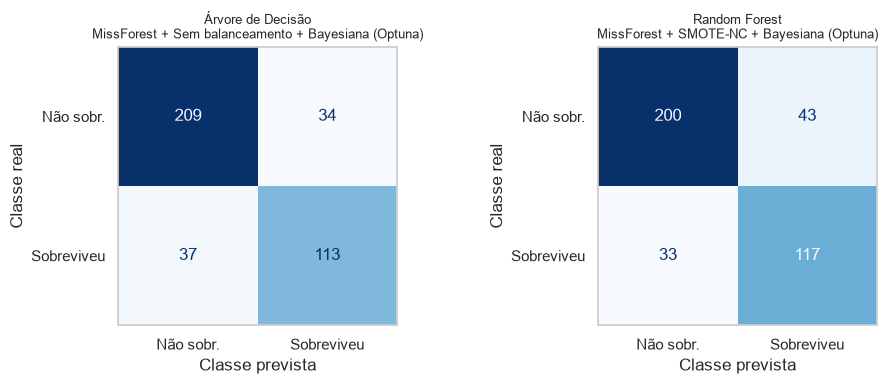

,Modelo,Imputação,Balanceamento,Otimizador,CV F1-macro,Acurácia treino,Acurácia,Precisão,Recall,F1,F1-macro,Precisão (0),Recall (0),Tempo (s)
0,Árvore de Decisão,MissForest,Sem balanceamento,Bayesiana (Optuna),0.786,0.835,0.819,0.769,0.753,0.761,0.808,0.850,0.860,1.409
1,Random Forest,MissForest,SMOTE-NC,Bayesiana (Optuna),0.799,0.828,0.807,0.731,0.780,0.755,0.798,0.858,0.823,18.340


In [23]:
melhor_rf = max([r for r in resultados if r['Modelo'] == 'Random Forest' and r['Imputação'] == IMPUTACAO_ESCOLHIDA],
                key=lambda r: r['CV F1-macro'])
fig, ax = plt.subplots(1, 2, figsize=(10, 4))
for i, r in enumerate([melhor_ad, melhor_rf]):
    Xte = dados[r['Imputação']]['teste']
    ConfusionMatrixDisplay.from_predictions(y_teste, r['estimador'].predict(Xte), display_labels=['Não sobr.', 'Sobreviveu'],
                                            cmap='Blues', colorbar=False, ax=ax[i])
    ax[i].grid(False)
    ax[i].set_xlabel('Classe prevista'); ax[i].set_ylabel('Classe real')
    ax[i].set_title(f"{r['Modelo']}\n{r['Imputação']} + {r['Balanceamento']} + {r['Otimizador']}", fontsize=9)
plt.tight_layout(); salvar_fig('matrizes_confusao'); plt.show()
pd.DataFrame([{k: r[k] for k in COLUNAS} for r in [melhor_ad, melhor_rf]]).round(3)

Médias sobre as 12 combinações de cada modelo:

| Modelo | Acurácia treino | CV F1-macro | Acurácia teste | F1 (1) teste | F1-macro teste | Gap treino − teste |
|---|---|---|---|---|---|---|
| Random Forest | 0,851 | 0,798 | 0,810 | 0,755 | 0,800 | 0,041 |
| Árvore de Decisão | 0,831 | 0,784 | 0,798 | 0,739 | 0,787 | 0,033 |

**A Random Forest generaliza melhor.** Seu F1-macro de validação cruzada é maior que o da Árvore de Decisão nas 12 combinações, e o F1-macro de teste é maior em 11 das 12. A única exceção (MissForest sem balanceamento, com Optuna) é um empate: 0,807 contra 0,808. A RF também é mais estável diante das escolhas de pré-processamento: a acurácia de teste varia de 0,794 a 0,830, contra 0,779 a 0,819 da árvore, cujo recall vai de 0,667 a 0,813.

O gap treino − teste um pouco maior da RF (4,1 contra 3,3 p.p.) não indica overfitting pior: ela ajusta melhor o treino e mesmo assim acerta mais fora dele, que é o que define a generalização. O gráfico acima compara os modelos escolhidos pela validação cruzada. A árvore sem balanceamento deixa passar mais sobreviventes (37 falsos negativos); a RF treinada com SMOTE-NC recupera 4 sobreviventes a mais ao custo de 9 falsos positivos a mais. Nesse par isolado a árvore teve F1-macro de teste um pouco maior (0,808 contra 0,798), uma diferença dentro do erro de ±2 p.p. que mostra por que decidir com base em um único modelo no teste seria arriscado.

### 4.c) Random Search × Otimização Bayesiana (Optuna)

In [24]:
otimizadores = metricas.groupby(['Modelo', 'Otimizador']).agg(
    **{'Tempo médio (s)': ('Tempo (s)', 'mean'), 'Tempo total (s)': ('Tempo (s)', 'sum'),
       'CV F1-macro médio': ('CV F1-macro', 'mean'), 'F1-macro teste médio': ('F1-macro', 'mean')})

par = metricas.pivot_table(index=['Modelo', 'Imputação', 'Balanceamento'], columns='Otimizador', values=['CV F1-macro', 'F1-macro', 'Tempo (s)'])
duelo = pd.DataFrame({
    'Δ CV (Optuna − Random)': par['CV F1-macro']['Bayesiana (Optuna)'] - par['CV F1-macro']['Random Search'],
    'Δ F1-macro teste (Optuna − Random)': par['F1-macro']['Bayesiana (Optuna)'] - par['F1-macro']['Random Search'],
    'Tempo Optuna / Random': par['Tempo (s)']['Bayesiana (Optuna)'] / par['Tempo (s)']['Random Search']})
print('Optuna com CV maior ou igual:', (duelo['Δ CV (Optuna − Random)'] >= 0).sum(), 'de', len(duelo))
display(otimizadores.round(3))
duelo.round(4)

Optuna com CV maior ou igual: 11 de 12


Tempo médio (s)  Tempo total (s)  CV F1-macro médio  F1-macro teste médio
Modelo            Otimizador                                                                                   
Random Forest     Bayesiana (Optuna)           13.870           83.222              0.799                 0.798
                  Random Search                10.475           62.848              0.797                 0.802
Árvore de Decisão Bayesiana (Optuna)            2.408           14.449              0.784                 0.789
                  Random Search                 1.357            8.139              0.783                 0.785

Δ CV (Optuna − Random)  Δ F1-macro teste (Optuna − Random)  Tempo Optuna / Random
Modelo            Imputação   Balanceamento                                                                                        
Random Forest     KNN Imputer RandomUnderSampler                  0.0010                             -0.0049                 1.2728
                              SMOTE-NC                            0.0041                              0.0034                 1.2548
                              Sem balanceamento                   0.0010                              0.0014                 1.2959
                  MissForest  RandomUnderSampler                  0.0040                             -0.0064                 1.3165
                              SMOTE-NC                            0.0036                             -0.0073                 1.4559
                              Sem balanceamento                   0.0004                             -0.0109                 1.3259
Árvore de Decisão KNN Imputer RandomUnderSampler                  0.0066                              0.0082                 1.8441
                              SMOTE-NC                           -0.0027                              0.0058                 1.5191
                              Sem balanceamento                   0.0018                             -0.0009                 2.9303
                  MissForest  RandomUnderSampler                  0.0009                              0.0047                 2.8285
                              SMOTE-NC                            0.0014                             -0.0049                 1.5392
                              Sem balanceamento                   0.0036                              0.0138                 1.8990

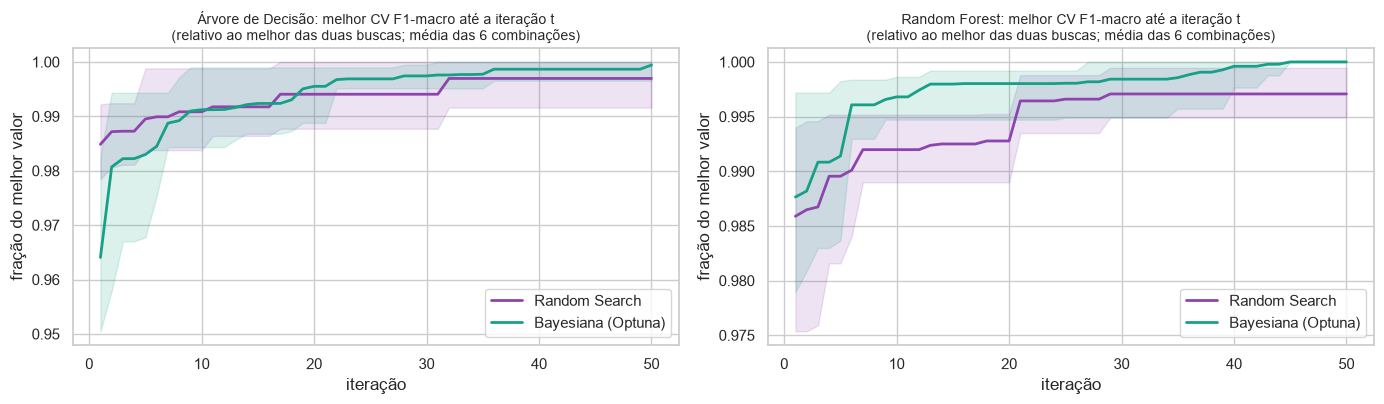

In [25]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.2))
for i, modelo in enumerate(MODELOS):
    for otim, cor in zip(OTIMIZADORES, ['#8e44ad', '#16a085']):
        curvas = np.array([r['historico'] for r in resultados if r['Modelo'] == modelo and r['Otimizador'] == otim])
        # normaliza pela melhor pontuação de cada combinação (a melhor dos dois otimizadores)
        melhores = np.array([max(r['CV F1-macro'] for r in resultados if r['Modelo'] == modelo and
                                 r['Imputação'] == q['Imputação'] and r['Balanceamento'] == q['Balanceamento'])
                             for q in resultados if q['Modelo'] == modelo and q['Otimizador'] == otim])
        rel = curvas / melhores[:, None]
        ax[i].plot(range(1, N_ITER + 1), rel.mean(axis=0), color=cor, lw=2, label=otim)
        ax[i].fill_between(range(1, N_ITER + 1), rel.min(axis=0), rel.max(axis=0), color=cor, alpha=.15)
    ax[i].set_title(f'{modelo}: melhor CV F1-macro até a iteração t\n(relativo ao melhor das duas buscas; média das 6 combinações)', fontsize=10)
    ax[i].set_xlabel('iteração'); ax[i].set_ylabel('fração do melhor valor'); ax[i].legend()
plt.tight_layout(); salvar_fig('convergencia'); plt.show()

In [26]:
# Tabela consolidada de hiperparâmetros (entregável): AD e RF lado a lado
hiperparametros = pd.concat([hiper_ad.assign(Modelo='Árvore de Decisão'), hiper_rf.assign(Modelo='Random Forest')])
hiperparametros = hiperparametros[['Modelo'] + [c for c in hiperparametros.columns if c != 'Modelo']]
hiperparametros.to_csv('tabelas/hiperparametros.csv', index=False)
hiperparametros

,Modelo,Imputação,Balanceamento,Otimizador,criterion,max_depth,min_samples_leaf,min_samples_split,CV F1-macro,Tempo (s),max_features,n_estimators
0,Árvore de Decisão,KNN Imputer,Sem balanceamento,Random Search,entropy,6,1,26,0.7888,0.6,NaN,NaN
1,Árvore de Decisão,KNN Imputer,Sem balanceamento,Bayesiana (Optuna),entropy,7,2,30,0.7906,1.6,NaN,NaN
2,Árvore de Decisão,KNN Imputer,SMOTE-NC,Random Search,gini,5,17,8,0.7857,3.2,NaN,NaN
3,Árvore de Decisão,KNN Imputer,SMOTE-NC,Bayesiana (Optuna),entropy,6,3,20,0.7830,4.9,NaN,NaN
4,Árvore de Decisão,KNN Imputer,RandomUnderSampler,Random Search,entropy,7,1,14,0.7804,1.0,NaN,NaN
5,Árvore de Decisão,KNN Imputer,RandomUnderSampler,Bayesiana (Optuna),gini,6,3,15,0.7870,1.9,NaN,NaN
6,Árvore de Decisão,MissForest,Sem balanceamento,Random Search,entropy,6,1,26,0.7826,0.7,NaN,NaN
7,Árvore de Decisão,MissForest,Sem balanceamento,Bayesiana (Optuna),gini,5,2,26,0.7863,1.4,NaN,NaN
8,Árvore de Decisão,MissForest,SMOTE-NC,Random Search,gini,5,17,8,0.7792,2.1,NaN,NaN
9,Árvore de Decisão,MissForest,SMOTE-NC,Bayesiana (Optuna),gini,4,11,9,0.7805,3.3,NaN,NaN


Médias por modelo e otimizador (24 buscas com 50 avaliações cada):

| Modelo | Otimizador | Tempo médio por busca (s) | CV F1-macro médio | F1-macro teste médio | Buscas com o maior CV |
|---|---|---|---|---|---|
| Árvore de Decisão | Random Search | 1,4 | 0,783 | 0,785 | 1 de 6 |
| Árvore de Decisão | Bayesiana (Optuna) | 2,4 | 0,784 | 0,789 | 5 de 6 |
| Random Forest | Random Search | 10,5 | 0,797 | 0,802 | 0 de 6 |
| Random Forest | Bayesiana (Optuna) | 13,9 | 0,799 | 0,798 | 6 de 6 |

**Hiperparâmetros encontrados.** Na mesma combinação, os valores escolhidos pelos dois otimizadores mudam bastante. Na RF com MissForest e sem balanceamento, o Optuna escolheu 58 árvores com max_depth = 14 e max_features = None, e o Random Search escolheu 103 árvores com max_depth = 10 e max_features = log2. Na árvore, o criterion trocou entre gini e entropy em 3 das 6 combinações. Ainda assim a qualidade é praticamente a mesma. O Optuna teve CV maior em 11 das 12 buscas, mas com ganho de no máximo 0,007 (0,002 em média). No teste, o F1-macro médio empatou (0,7935 contra 0,7934), com o Optuna à frente em só 6 das 12 combinações. **A diferença nos hiperparâmetros é grande, mas a diferença na qualidade não é significativa.** A superfície de desempenho é um platô largo, em que configurações muito diferentes chegam ao mesmo F1.

**Eficiência.** No gráfico acima, o Optuna começa atrás na árvore, porque suas 10 primeiras tentativas são aleatórias, passa o Random Search por volta da 17ª iteração e termina com 99,9% do melhor valor, contra 99,7%. Na RF ele fica à frente desde as primeiras iterações. Em tempo, porém, o Optuna custou em média 2,1 vezes o tempo do Random Search na árvore e 1,3 vezes na RF. O RandomizedSearchCV envia os 250 treinos (50 configurações × 5 folds) de uma vez para os processos paralelos. O Optuna precisa concluir uma tentativa para escolher a próxima, o que deixa núcleos ociosos e pesa mais quando cada treino dura milissegundos, como na árvore. **Neste problema, o Random Search teve a melhor relação entre tempo e qualidade:** chegou, em média, a 99,7% do melhor valor gastando menos tempo. A vantagem do Optuna aparece quando cada avaliação é cara ou o espaço de busca é grande, e aqui, com 4 ou 5 hiperparâmetros e uma base pequena, nenhuma das duas condições vale.

### 4.d) KNN Imputer × MissForest

In [27]:
por_imputacao = metricas.groupby(['Modelo', 'Imputação'])[['CV F1-macro', 'Acurácia', 'Precisão', 'Recall', 'F1', 'F1-macro']].mean()
display(por_imputacao.round(3))
tabela_imputacao[['Média', 'Desvio', 'Mediana', 'Assimetria', 'KS', 'Wasserstein', 'corr(age, pclass)', 'MAE mascarado', 'RMSE mascarado']].round(3)

CV F1-macro  Acurácia  Precisão  Recall     F1  F1-macro
Modelo            Imputação                                                            
Random Forest     KNN Imputer        0.801     0.807     0.741   0.764  0.752     0.797
                  MissForest         0.796     0.813     0.748   0.771  0.759     0.803
Árvore de Decisão KNN Imputer        0.786     0.791     0.722   0.739  0.729     0.779
                  MissForest         0.781     0.805     0.738   0.761  0.749     0.795

,Média,Desvio,Mediana,Assimetria,KS,Wasserstein,"corr(age, pclass)",MAE mascarado,RMSE mascarado
Método,,,,,,,,,
Original (observado),30.080,14.075,29.000,0.333,0.000,0.000,-0.438,NaN,NaN
KNN Imputer,29.865,13.284,28.000,0.326,0.064,0.844,-0.446,8.683,11.285
MissForest,29.889,13.236,28.354,0.336,0.036,0.909,-0.449,8.552,11.241
Mediana por título (Lista 2),29.719,12.968,30.000,0.370,0.060,1.481,-0.418,9.005,11.928


Médias por modelo e método de imputação:

| Modelo | Imputação | CV F1-macro | Acurácia teste | Precisão (1) | Recall (1) | F1-macro teste |
|---|---|---|---|---|---|---|
| Árvore de Decisão | KNN Imputer | 0,786 | 0,791 | 0,722 | 0,739 | 0,779 |
| Árvore de Decisão | MissForest | 0,781 | 0,805 | 0,738 | 0,761 | 0,795 |
| Random Forest | KNN Imputer | 0,801 | 0,807 | 0,741 | 0,764 | 0,797 |
| Random Forest | MissForest | 0,796 | 0,813 | 0,748 | 0,771 | 0,803 |

**Desempenho final: não houve diferença relevante.** Os dois critérios apontam em sentidos opostos. No teste, o MissForest ficou à frente (+1,6 p.p. de F1-macro na árvore e +0,6 p.p. na RF); na validação cruzada, calculada em 5 folds sobre os 916 passageiros de treino, o KNN ficou à frente (+0,5 p.p. nos dois modelos). Diferenças desse tamanho e com sinais trocados estão dentro do ruído de amostragem. Isso é coerente com o problema: *age* é só o 4º atributo em importância (0,09), os ausentes são 20% de um único atributo e as idades imputadas pelos dois métodos são parecidas em média (28,9 e 29,1 anos).

**Distribuição original: o MissForest a preservou melhor**. Teve KS de 0,036 (p = 0,66) contra 0,064 (p = 0,067), assimetria igual à original e menor erro ao recuperar idades escondidas (MAE de 8,55 contra 8,68). O KNN só leva vantagem na distância de Wasserstein (0,84 contra 0,91) e no tempo de execução.

### 4.e) SMOTE (SMOTE-NC) × RandomUnderSampler — equilíbrio entre precisão e recall da classe minoritária

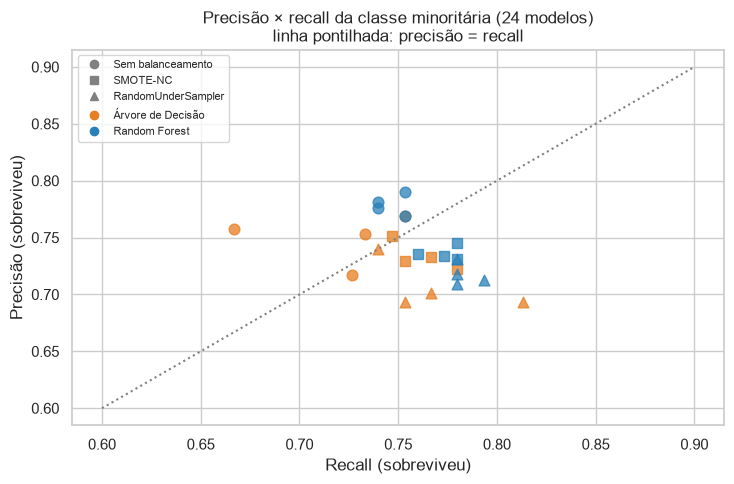

Precisão  Recall     F1  Precisão (0)  Recall (0)  F1-macro  Acurácia  |Precisão − Recall|
Modelo            Balanceamento                                                                                                 
Random Forest     RandomUnderSampler     0.718   0.783  0.749         0.858       0.810     0.791     0.800                0.066
                  SMOTE-NC               0.737   0.773  0.754         0.856       0.829     0.798     0.808                0.037
                  Sem balanceamento      0.779   0.747  0.763         0.848       0.869     0.810     0.823                0.033
Árvore de Decisão RandomUnderSampler     0.707   0.768  0.736         0.849       0.802     0.780     0.789                0.061
                  SMOTE-NC               0.734   0.762  0.747         0.849       0.829     0.793     0.803                0.028
                  Sem balanceamento      0.749   0.720  0.734         0.831       0.851     0.787     0.801                0.029

In [28]:
por_balanceamento = metricas.groupby(['Modelo', 'Balanceamento'])[['Precisão', 'Recall', 'F1', 'Precisão (0)', 'Recall (0)', 'F1-macro', 'Acurácia']].mean()
por_balanceamento['|Precisão − Recall|'] = (por_balanceamento['Precisão'] - por_balanceamento['Recall']).abs()
por_balanceamento.to_csv('tabelas/por_balanceamento.csv')

fig, ax = plt.subplots(figsize=(7.5, 5))
marcadores = {'Sem balanceamento': 'o', 'SMOTE-NC': 's', 'RandomUnderSampler': '^'}
cores_modelo = {'Árvore de Decisão': '#e67e22', 'Random Forest': '#2980b9'}
for _, r in metricas.iterrows():
    ax.scatter(r['Recall'], r['Precisão'], marker=marcadores[r['Balanceamento']], color=cores_modelo[r['Modelo']], s=60, alpha=.75)
ax.plot([0.6, 0.9], [0.6, 0.9], ls=':', color='gray')
from matplotlib.lines import Line2D
ax.legend(handles=[Line2D([], [], marker=m, ls='', color='gray', label=b) for b, m in marcadores.items()] +
                  [Line2D([], [], marker='o', ls='', color=c, label=mo) for mo, c in cores_modelo.items()], fontsize=8)
ax.set_xlabel('Recall (sobreviveu)'); ax.set_ylabel('Precisão (sobreviveu)')
ax.set_title('Precisão × recall da classe minoritária (24 modelos)\nlinha pontilhada: precisão = recall')
plt.tight_layout(); salvar_fig('precisao_recall'); plt.show()
por_balanceamento.round(3)

Médias por modelo e técnica de balanceamento (classe 1 = sobreviveu, minoritária):

| Modelo | Balanceamento | Precisão (1) | Recall (1) | |Precisão − Recall| | F1 (1) | Recall (0) | F1-macro |
|---|---|---|---|---|---|---|---|
| Árvore de Decisão | Sem balanceamento | 0,749 | 0,720 | 0,029 | 0,734 | 0,851 | 0,787 |
| Árvore de Decisão | SMOTE-NC | 0,734 | 0,762 | 0,028 | 0,747 | 0,829 | 0,793 |
| Árvore de Decisão | RandomUnderSampler | 0,707 | 0,768 | 0,061 | 0,736 | 0,802 | 0,780 |
| Random Forest | Sem balanceamento | 0,779 | 0,747 | 0,033 | 0,763 | 0,869 | 0,810 |
| Random Forest | SMOTE-NC | 0,737 | 0,773 | 0,037 | 0,754 | 0,829 | 0,798 |
| Random Forest | RandomUnderSampler | 0,718 | 0,783 | 0,066 | 0,749 | 0,810 | 0,791 |

**O SMOTE-NC produziu o melhor equilíbrio entre precisão e recall da classe minoritária.** Nos dois modelos ele manteve precisão e recall próximos (diferença de 2,8 p.p. na árvore e 3,7 p.p. na RF) e obteve F1 da classe sobreviveu maior que o do RandomUnderSampler. O RandomUnderSampler dá o maior recall (0,768 e 0,783), mas com a menor precisão (0,707 e 0,718) e a maior distância entre as duas (6,1 e 6,6 p.p.). Ao descartar 38% dos não sobreviventes, o modelo vê menos exemplos de quem morreu e passa a prever "sobreviveu" com mais facilidade, gerando mais falsos positivos: o recall da classe 0 cai para 0,80 e 0,81. No gráfico acima, os triângulos (RandomUnderSampler) ficam abaixo e à direita da diagonal, e os quadrados (SMOTE-NC) ficam mais perto dela.

Em relação a não balancear, o efeito depende do modelo. Na árvore, o SMOTE-NC aumentou o recall dos sobreviventes em 4,2 p.p. e o F1 em 1,3 p.p. Na RF, o melhor F1 e o melhor F1-macro vieram *sem* balanceamento: com um desbalanceamento de apenas 1,62 : 1, a floresta já separa bem as classes, e balancear apenas desloca o ponto de operação, trocando precisão por recall. Para não deixar de identificar sobreviventes, o SMOTE-NC é a melhor escolha; para acertar o máximo no geral, não balancear foi suficiente na RF.

### 4.f) As regras da Árvore continuam interpretáveis no Random Forest?

In [29]:
floresta = melhor_rf['estimador'].named_steps['modelo']
nomes_rf = list(CodificadorOneHot().transform(dados[melhor_rf['Imputação']]['treino']).columns)
raizes = pd.Series([nomes_rf[e.tree_.feature[0]] for e in floresta.estimators_]).value_counts()
folhas_rf = [e.get_n_leaves() for e in floresta.estimators_]
prof_rf = [e.get_depth() for e in floresta.estimators_]
print(f"Random Forest ({melhor_rf['Imputação']} + {melhor_rf['Balanceamento']} + {melhor_rf['Otimizador']}): {melhor_rf['params']}")
print(f'Árvores: {len(floresta.estimators_)} | profundidade média: {np.mean(prof_rf):.1f} | '
      f'folhas por árvore: {np.mean(folhas_rf):.0f} (média) | regras no total: {sum(folhas_rf)}')
print(f'Árvore de Decisão: profundidade {arvore.get_depth()} | regras: {arvore.get_n_leaves()}')
print('\nAtributo usado na raiz de cada árvore da floresta:')
print(raizes.to_string())
for i in range(2):
    print(f'\n--- Árvore {i} da floresta (2 primeiros níveis) ---')
    print(export_text(floresta.estimators_[i], feature_names=nomes_rf, max_depth=2, decimals=2))

Random Forest (MissForest + SMOTE-NC + Bayesiana (Optuna)): {'n_estimators': 215, 'max_depth': 10, 'min_samples_split': 15, 'min_samples_leaf': 9, 'max_features': 'log2'}
Árvores: 215 | profundidade média: 9.3 | folhas por árvore: 36 (média) | regras no total: 7798
Árvore de Decisão: profundidade 5 | regras: 21

Atributo usado na raiz de cada árvore da floresta:
titulo_Mr      43
sexo           41
titulo_Mrs     30
titulo_Miss    26
tem_cabine     24
fare           20
pclass         16
tam_familia     9
parch           3
embarked_S      2
sozinho         1

--- Árvore 0 da floresta (2 primeiros níveis) ---
|--- fare <= 26.02
|   |--- titulo_Mrs <= 0.50
|   |   |--- titulo_Miss <= 0.50
|   |   |   |--- truncated branch of depth 7
|   |   |--- titulo_Miss >  0.50
|   |   |   |--- truncated branch of depth 5
|   |--- titulo_Mrs >  0.50
|   |   |--- embarked_S <= 0.50
|   |   |   |--- class: 1.0
|   |   |--- embarked_S >  0.50
|   |   |   |--- truncated branch of depth 4
|--- fare >  26.02

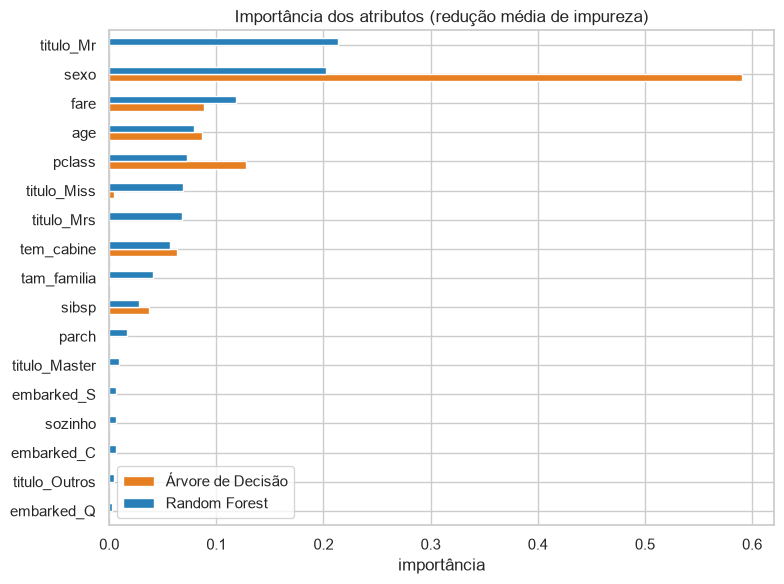

arvores                                                       215
prof_media                                               9.325581
folhas_media                                            36.269767
regras_total                                                 7798
raizes          {'titulo_Mr': 43, 'sexo': 41, 'titulo_Mrs': 30...
ad_prof                                                         5
ad_folhas                                                      21
dtype: object

In [30]:
importancias = pd.DataFrame({'Árvore de Decisão': importancia_ad,
                             'Random Forest': pd.Series(floresta.feature_importances_, index=nomes_rf)}).fillna(0)
importancias = importancias.sort_values('Random Forest', ascending=True)
importancias.to_csv('tabelas/importancias.csv')
importancias.plot(kind='barh', figsize=(8, 6), color=['#e67e22', '#2980b9'])
plt.title('Importância dos atributos (redução média de impureza)'); plt.xlabel('importância')
plt.tight_layout(); salvar_fig('importancias'); plt.show()

resumo_rf = {'arvores': len(floresta.estimators_), 'prof_media': float(np.mean(prof_rf)), 'folhas_media': float(np.mean(folhas_rf)),
             'regras_total': int(sum(folhas_rf)), 'raizes': raizes.to_dict(),
             'ad_prof': int(arvore.get_depth()), 'ad_folhas': int(arvore.get_n_leaves())}
pd.Series(resumo_rf)

**Não da mesma forma.** A Árvore de Decisão escolhida tem 21 regras com profundidade de até 5, e cada previsão segue um único caminho legível. A Random Forest escolhida (MissForest + SMOTE-NC + Optuna: 215 árvores, max_depth = 10, max_features = log2) tem árvores com profundidade média de 9,3 e cerca de 36 folhas cada, ou seja, **7.798 regras**, e a previsão é o voto de todas elas. Não existe "a regra" da floresta.

As árvores da floresta também não repetem a árvore única. *sexo*, raiz da Árvore de Decisão, é raiz de só 41 das 215 árvores (19%); as demais começam por *titulo_Mr* (43), *titulo_Mrs* (30), *titulo_Miss* (26), *tem_cabine* (24), *fare* (20), *pclass* (16) e outros. Com max_features = log2, cada divisão sorteia só 4 dos 16 atributos, e quando *sexo* não é sorteado a árvore usa um substituto, como o título. No gráfico acima, a importância concentrada em *sexo* na árvore (0,59) aparece dividida na floresta entre *titulo_Mr* (0,21), *sexo* (0,20) e os outros títulos. O padrão global continua o mesmo (sexo e título, tarifa, idade, classe), mas só pode ser lido de forma agregada, pela importância dos atributos, e não como regras SE–ENTÃO.

**Por que a RF prevê melhor?** Uma única árvore tem baixo viés e alta variância: pequenas mudanças no treino alteram os cortes, como na Lista 2, em que a raiz mudou conforme a amostra de treino. A RF treina cada árvore em uma amostra bootstrap e sorteia atributos a cada divisão, o que gera árvores diferentes e pouco correlacionadas. A média dos votos cancela boa parte dos erros individuais e reduz a variância sem aumentar o viés. Foi isso que produziu o CV maior nas 12 combinações e os resultados mais estáveis entre pré-processamentos.

**Por que é menos interpretável?** Pelo mesmo motivo: a decisão fica distribuída entre centenas de árvores diferentes. A importância dos atributos mostra *quais* atributos pesam, mas não *como* pesam (limiares, interações, direção do efeito), e reunir 7.798 regras em uma explicação legível não é viável. Explicar uma RF exige aproximações, como importância por permutação, SHAP ou uma árvore substituta treinada para imitar a floresta, e essas aproximações já não são o modelo em si. É o compromisso clássico: a Árvore de Decisão entrega regras auditáveis com F1-macro cerca de 1,3 p.p. menor, e a Random Forest ganha desempenho e estabilidade às custas da transparência.

## 5. Conclusão

A imputação e o balanceamento importaram menos que a escolha do modelo. Entre os imputadores, o MissForest preservou melhor a distribuição de *age* (KS de 0,036 contra 0,064, assimetria mantida e menor erro nas idades escondidas), mas o desempenho final dos modelos não mudou de forma relevante: o MissForest ficou à frente no teste e o KNN na validação cruzada, sempre por menos de 2 p.p. (4.d). Entre as técnicas de balanceamento, o SMOTE-NC deu o melhor equilíbrio entre precisão e recall dos sobreviventes, enquanto o RandomUnderSampler ganhou recall à custa de precisão ao descartar 38% dos não sobreviventes. Com um desbalanceamento moderado (1,62 : 1), porém, não balancear continuou competitivo, sobretudo na Random Forest (4.e). O SMOTE clássico foi substituído pelo SMOTE-NC porque gerava categorias impossíveis, como sexo = 0,37, que produziam regras falsas.

Entre os otimizadores, Random Search e Otimização Bayesiana chegaram a hiperparâmetros bem diferentes, mas de qualidade equivalente. O Optuna venceu na validação em 11 das 12 buscas com ganho médio de apenas 0,002 e empatou no teste, enquanto o Random Search foi mais rápido. Neste problema, com espaço de busca pequeno e modelos baratos, o Random Search teve a melhor relação entre tempo e qualidade (4.c). A Random Forest generalizou melhor que a Árvore de Decisão: F1-macro de validação maior nas 12 combinações, maior no teste em 11 delas e menor variação entre pré-processamentos (4.b), graças à redução de variância obtida com bootstrap e sorteio de atributos. O preço é a interpretabilidade: as 21 regras da árvore dão lugar a 7.798 regras espalhadas por 215 árvores com raízes diferentes, e o padrão só pode ser lido de forma agregada (4.f).

O padrão de sobrevivência se manteve em todas as análises e confirma a Lista 2. O sexo é o fator decisivo: tem 59% da importância na árvore e, na floresta, sexo e títulos somam 0,57, com Mr, Mrs e Miss atuando como substitutos do sexo. Sobreviveram as mulheres de 1ª e 2ª classe e os meninos de famílias pequenas; morreram os homens adultos de 2ª e 3ª classe e as famílias numerosas da 3ª classe.

> Achado principal: sobreviveram as mulheres das classes altas e as crianças de famílias pequenas; morreram os homens adultos de 2ª e 3ª classe e as famílias numerosas da 3ª classe. A Random Forest prevê esse padrão melhor, mas só a Árvore de Decisão o explica em regras.